In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison
import dotenv
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LogNorm
# import environment variables

dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")

import pickle

In [3]:
    def plot_trial_latents_new(self, num_trials=10, pca=False, n_components=2, avg_per_rate=True,
                               xstar=None, is_stable=None, phase="all", inputs_latents=None,
                               plot_wrapper_trajs=False, input_latents_extra=None, scatter_trajectories=False,
                               timescales=None, cluster_centers=None, cluster_is_stable=None, t_min=5.0, t_max=10.0,
                              timescale_cmap=None, pca_obj=None, ics_dim=2):
        """
        Plot latent trajectories for trials ran during training, with
        predetermined train/val inputs.
        """
        
        # Get the dynamics model
        model = self.get_dynamics_model()
        labels = input_latents_extra
        
        ic_point = np.zeros((2000, ics_dim))
        
        input_latents = torch.tensor(inputs_latents, dtype=torch.float32)
        
        if isinstance(ic_point, np.ndarray):
            ic_point = torch.tensor(ic_point, dtype=torch.float32)
        
        # Add batch dimension if not present
        if len(ic_point.shape) == 1:
            ic_point = ic_point.unsqueeze(0)  # [1, latent_size]
        
        # Create input sequence by repeating the same input for each time step
        # Shape: [B=1, T=num_steps, input_size]
        #inputs_latents = input_latents.unsqueeze(0).unsqueeze(0).expand(B, 170, -1)  ONLY FOR PCA GEN
        
        # Generate trajectory
        with torch.no_grad():
            hidden = ic_point
            states = []
            
            # Now correctly transpose to get [T, B, input_size]
            for input_step in input_latents.transpose(1, 0):  # Note: transpose 1,0 not 0,1
                hidden = model(input_step, hidden)
                states.append(hidden.clone())
            
            # Stack states into trajectory
            latents= torch.stack(states, dim=1)  # [B, T, latent_size]
    


        # Check if the latent dimension is at least equal to n_components
        if latents.shape[-1] < n_components:
            raise ValueError(f"Latent dimension ({latents.shape[-1]}) must be at least equal to n_components ({n_components}).")

        # Apply PCA if specified
        if pca:
            B, T, N = latents.shape
            latents_flat = latents.reshape(-1, N).squeeze()
#             if pca_obj is None:
            pca_model = PCA(n_components=n_components)
            pca_model.fit(latents_flat)
                
            latents_pca = pca_model.transform(latents_flat)
            latents_pca = latents_pca.reshape(B, T, n_components)

            # Get explained variance
            explained_variance = pca_model.explained_variance_ratio_
            print(f"PCA explained variance: {' '.join([f'PC{i+1}={var:.4f}' for i, var in enumerate(explained_variance)])}")
            print(f"Total variance explained: {np.sum(explained_variance):.4f}")

            # Use PCA transformed latents
            latents = latents_pca

        # Average latents if specified
        if avg_per_rate:
            fig, ax = plt.subplots()
            if n_components==3:
                ax = fig.add_subplot(111, projection='3d')  # Set 3D projection
                
            unique_labels = np.unique(labels[:, 1])
            for i, label in enumerate(unique_labels):
                # Find the indices of latents with the current label
                indices = np.where(labels[:, 1] == label)[0]
                # Get the aligned average of the latents by phase
                delay, stim, resp = self.average_latents_by_phase_new(inputs_latents[indices], latents[indices])

                # if all inputs were zero (no stim - don't need phases)
                if type(delay) == int:  # if all returned zero
                    print("Plotting for all zero inputs - no phase averaging")
                    cat = np.mean(latents[indices], axis=0)
                else:  
                    print("Plotting for non-trivial inputs with phase averaging")
                    if phase == "all":
                        cat = np.concatenate((delay, stim, resp), axis=0)
                    elif phase == "delay":
                        cat = delay
                    elif phase == "stim":
                        cat = stim
                    elif phase == "resp":
                        cat = resp

                norm_labels = plt.Normalize(1,39)
                # plot all the latents for this label
                if scatter_trajectories:
                    # can color each phase different
                    c = np.linspace(0, 1, cat.shape[0])
                    ax.scatter(*cat.T, s=10, color=plt.get_cmap('YlOrBr')(c))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    # concatenate to make a continuous time series and color by label
                    ax.plot(*cat.T, linewidth=1.5, color=plt.get_cmap('coolwarm')(norm_labels(label)))
 
                # # concatenate to make a continuous time series and color by label
                # ax.plot(*cat.T, linewidth=1.5, color=plt.cm.coolwarm(norm_labels(label)))

            # Set axis labels with explained variance if using PCA
            if pca:
                if n_components >= 1:
                    ax.set_xlabel(f"PC1 ({explained_variance[0]:.1%} var)", fontsize=14)
                if n_components >= 2:
                    ax.set_ylabel(f"PC2 ({explained_variance[1]:.1%} var)", fontsize=14)
                    
             # plot fixed points - especially for models w/o flow fields 
            if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
                print(f"Plotting {xstar.shape[0]} fixed points")
                
                if pca:
                    xstar_pca = pca_model.transform(xstar)
                    stable_points = xstar_pca[is_stable]
                    unstable_points = xstar_pca[~is_stable]
                else:
                    stable_points = xstar[is_stable]
                    unstable_points = xstar[~is_stable]
                    
                # color by timescale (only decaying modes)
                if len(timescales) > 0:
                    if pca:
                        centers = pca_model.transform(cluster_centers)
                    else:
                        centers = cluster_centers

                    stable_points = centers[cluster_is_stable]
                    unstable_points = centers[~cluster_is_stable]
                    timescales_stable = timescales[cluster_is_stable]
                    timescales_unstable = timescales[~cluster_is_stable]
                    # Color by timescale (both decaying and growing modes)
                    is_special = timescales_unstable == -1
                    is_valid_stable = ~np.isnan(timescales_stable)
                    is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special
                    # Combine all valid timescales for normalization
                    all_valid_timescales = []
                    if np.any(is_valid_stable):
                        all_valid_timescales.extend(timescales_stable[is_valid_stable])
                    if np.any(is_valid_unstable):
                        all_valid_timescales.extend(timescales_unstable[is_valid_unstable])
                    if len(all_valid_timescales) > 0:
                        # Create a symmetric normalization around 0
                        norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value
                        # Plot valid stable points with continuous colormap
                        if np.any(is_valid_stable):
                            sc_stable = ax.scatter(
                                *stable_points[is_valid_stable].T, 
                                c=timescales_stable[is_valid_stable], 
                                cmap=timescale_cmap, 
                                marker='o', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2,
                            )
                        # add the colorbar
                        if np.any(is_valid_stable) or np.any(is_valid_unstable):
                            sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                            plt.colorbar(sc, ax=ax, label='Timescale (s)')
                else:
                    # Plot stable points (green circles)
                    ax.scatter(*stable_points.T, c='limegreen', marker='o')

                    # Plot unstable points (brown crosses)
                    ax.scatter(*unstable_points.T, c='red', marker='x')
            # Set the face color of the plot to a specific shade of teal
            ax.set_facecolor("#f2f2f2")  # Replace "#008080" with your teal color code

            plt.title("Averaged Latent Trajectories by Rate", fontsize=16)
            plt.tight_layout()
            
            return fig,ax

        # Determine plot type (2D or 3D)
        is_3d = n_components == 3 or (not pca and latents.shape[-1] == 3)
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d" if is_3d else None)

        # Plot latents colored by rate instead of by trial
        norm_labels = plt.Normalize(1, 39)
        for i in range(min(num_trials, latents.shape[0])):
            rate = labels[i, 1]  # Get the rate for this trial
            color = plt.cm.coolwarm(norm_labels(rate))

            if is_3d:
                ax.plot(latents[i, :, 0], latents[i, :, 1], latents[i, :, 2], 
                        color=color, linewidth=1.5, label=f"{rate} Hz" if i == 0 else "")
            else:
                ax.plot(latents[i, :, 0], latents[i, :, 1], 
                        color=color, linewidth=1.5, label=f"{rate} Hz" if i == 0 else "")
             
        # plot fixed points - especially for models w/o flow fields 
        if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
            print(f"Plotting {xstar.shape[0]} fixed points")
            
            if pca:
                xstar_pca = pca_model.transform(xstar)
                stable_points = xstar_pca[is_stable]
                unstable_points = xstar_pca[~is_stable]
            else:
                stable_points = xstar[is_stable]
                unstable_points = xstar[~is_stable]
                
            # color by timescale (only decaying modes)
            if len(timescales) > 0:
                if pca:
                    centers = pca_model.transform(cluster_centers)
                else:
                    centers = cluster_centers
                    
                stable_points = centers[cluster_is_stable]
                unstable_points = centers[~cluster_is_stable]
                timescales_stable = timescales[cluster_is_stable]
                timescales_unstable = timescales[~cluster_is_stable]
                # Color by timescale (both decaying and growing modes)
                is_special = timescales_unstable == -1
                is_valid_stable = ~np.isnan(timescales_stable)
                is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special
                # Combine all valid timescales for normalization
                all_valid_timescales = []
                if np.any(is_valid_stable):
                    all_valid_timescales.extend(timescales_stable[is_valid_stable])
                if np.any(is_valid_unstable):
                    all_valid_timescales.extend(timescales_unstable[is_valid_unstable])
                if len(all_valid_timescales) > 0:
                    # Create a symmetric normalization around 0
                    norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value
                    # Plot valid stable points with continuous colormap
                    if np.any(is_valid_stable):
                        sc_stable = ax.scatter(
                            *stable_points[is_valid_stable].T, 
                            c=timescales_stable[is_valid_stable], 
                            cmap=timescale_cmap, 
                            marker='o', 
                            s=60, 
                            norm=norm, 
                            edgecolors='white', # edge color
                            linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2,
                            )
                    # add the colorbar
                    if np.any(is_valid_stable) or np.any(is_valid_unstable):
                        sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                        plt.colorbar(sc, ax=ax, label='Timescale (s)')
            else:
                # Plot stable points (green circles)
                ax.scatter(*stable_points.T, c='limegreen', marker='o')
                
                # Plot unstable points (brown crosses)
                ax.scatter(*unstable_points.T, c='red', marker='x')      

        # Set axis labels with explained variance if using PCA
        if pca:
            if n_components >= 1:
                ax.set_xlabel(f"PC1 ({explained_variance[0]:.1%} var)", fontsize=14)
            if n_components >= 2:
                ax.set_ylabel(f"PC2 ({explained_variance[1]:.1%} var)", fontsize=14)
            if n_components >= 3 and is_3d:
                ax.set_zlabel(f"PC3 ({explained_variance[2]:.1%} var)", fontsize=14)
        else:
            ax.set_xlabel("$lat_1$", fontsize=14)
            ax.set_ylabel("$lat_2$", fontsize=14)
            if is_3d:
                ax.set_zlabel("$lat_3$", fontsize=14)

        # # Add colorbar for rate
        # norm = plt.Normalize(1, 39)
        # sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
        # sm.set_array([])
        # cbar = plt.colorbar(sm, ax=ax)
        # cbar.set_label('Rate (Hz)', fontsize=12)

        # Set grid color to white and adjust axis labels
        ax.tick_params(axis='both', which='major', labelsize=16)

        # Set the face color of the plot to a specific shade of teal
        ax.set_facecolor("#f2f2f2")  # Replace "#008080" with your teal color code

        plt.tight_layout()
        
        return fig

In [22]:
    def plot_flow_field_new(self, latents_range: list, num_points: int, inputs_latents: np.array, input_field: np.array,  
                    input_latents_extra: np.array=None, custom_n_timesteps: int=None, n_trials=10, 
                    scatter_trajectories=False, xstar=None, is_stable=None,  plot_wrapper_trajs=False, 
                    filter_pc_rate:int=None, avg_per_rate=False, lint_plot_style=False, 
                    cmap_field=plt.get_cmap('pink'), cmap_time=plt.get_cmap('copper'), cmap_rate=plt.get_cmap('coolwarm'),
                    ics_noise=None, pca=True, koopman=False, phase='all', ortho_koopman=False, timescales=None, 
                    cluster_centers=None, cluster_is_stable=None, t_min=5.0, t_max=10.0,timescale_cmap=plt.get_cmap('cool'), 
                    pca_obj=None, field_color_only=False, title="set title",ics_dim=2 ,**kwargs):
    
        # Get the dynamics model
        model = self.get_dynamics_model()
        
        # Ensure input_field is a tensor
        if isinstance(input_field, np.ndarray):
            input_field = torch.tensor(input_field, dtype=torch.float32)
            
        B = 2000
            
        ic_point = np.zeros((B, ics_dim))
#         input_latents = np.array([0,0,0])  ONLY FOR PCA GEN
        input_latents = torch.tensor(inputs_latents, dtype=torch.float32)
        
        # Ensure ic_point is a tensor with batch dimension
        if isinstance(ic_point, np.ndarray):
            ic_point = torch.tensor(ic_point, dtype=torch.float32)
        
        # Add batch dimension if not present
        if len(ic_point.shape) == 1:
            ic_point = ic_point.unsqueeze(0)  # [1, latent_size]
        
        # Create input sequence by repeating the same input for each time step
        # Shape: [B=1, T=num_steps, input_size]
        #inputs_latents = input_latents.unsqueeze(0).unsqueeze(0).expand(B, 170, -1)  ONLY FOR PCA GEN
        
        # Generate trajectory
        with torch.no_grad():
            hidden = ic_point
            states = []
            
            # Now correctly transpose to get [T, B, input_size]
            for input_step in input_latents.transpose(1, 0):  # Note: transpose 1,0 not 0,1
                hidden = model(input_step, hidden)
                states.append(hidden.clone())
            
            # Stack states into trajectory
            latents= torch.stack(states, dim=1)  # [B, T, latent_size]
    
    
#         # GET THE GLOBAL PCA OBJECT ON THE GENERATIVE LATENTS
#         latents = latents.detach().numpy()
#         model_global = self.model
#         C = model_global.readout.weight.detach().numpy()
#         U, S, VT = np.linalg.svd(C)
#         S_diag = np.diag(S)
        
#         # Compute A = S_diag @ VT using numpy's dot product
#         A = np.dot(S_diag, VT)
        
#         # Flatten batch and sequence dimensions
#         batch_size, seq_len, latent_dim = latents.shape
#         latents_reshaped = np.reshape(latents, (-1, latent_dim))
        
#         # Compute semi-orthogonalized latents 
#         latents_reshaped_T = np.transpose(latents_reshaped)
#         temp = np.dot(A, latents_reshaped_T)
#         latents_semi_orthog = np.transpose(temp)
        
#         # Do PCA on the semi-orthogonalized latents
#         pca = PCA(n_components=2)
#         pca.fit(latents_semi_orthog)
        
        
#         PCA_GLOBAL = pca
        
#         print("PCA GLOBAL DONE, SAVE")
        
#         with open("pca_object_dd_axes.pkl", "wb") as f:
#             pickle.dump(PCA_GLOBAL, f)

        input_field = torch.unsqueeze(input_field, 0)
        
            
#             if custom_n_timesteps is not None and custom_n_timesteps > t:
#                 raise ValueError("got more timesteps than in inputs_latents. Reduce custom_n_timesteps")
            # run inference with custom value
#             # HERE will need ICA - default to zero init
#             latents = model(inputs_latents, ics) # ONLY DECODER!!
            #out_dict = self.wrapper(tt_ics, inputs_latents, inputs_to_env, custom_n_timesteps=custom_n_timesteps)
            #latents = out_dict["latents"].detach().numpy()
        

        if input_latents_extra is not None:
            labels = input_latents_extra
            
#         if latents.shape[-1] > 3 and not pca:
#             raise ValueError("Latents have more than 3 dimensions. Not supported without PCA")
        elif latents.shape[-1] != len(latents_range) and not pca:
            raise ValueError("Adjust latents_range to dimension ", latents.shape[-1])

        
#         input_field = torch.unsqueeze(input_field, 0)
        
        if pca:
            # get only the pca object always on the wrapper latents
#             latents_ref = self.get_latents().detach().numpy()
            latents_ref = latents.clone()
            flattened_latents = latents_ref.reshape(-1, latents_ref.shape[-1])
            if pca_obj is None:
                pca_obj = PCA(n_components=2)
                pca_obj.fit(flattened_latents)
            
            # Calculate PCA space limits for creating the grid
            latents_pca = pca_obj.transform(flattened_latents)
            
            # Get explained variance
            explained_variance = pca_obj.explained_variance_ratio_
            print(f"PCA explained variance: PC1={explained_variance[0]:.4f}, PC2={explained_variance[1]:.4f}")
            print(f"Total variance explained: {np.sum(explained_variance):.4f}")
            
            # Determine appropriate range in PCA space
            x_min, x_max = np.min(latents_pca[:, 0])-0.5, np.max(latents_pca[:, 0])+0.5
            y_min, y_max = np.min(latents_pca[:, 1])-0.5, np.max(latents_pca[:, 1])+0.5
            
            # Override latents_range with PCA ranges
            pca_range = [[x_min, x_max], [y_min, y_max]]
            
        elif koopman:
            latents_ref = self.get_latents()  # PyTorch tensor
            koopman_modes, eigenvalues, mean_latent = self.compute_koopman(latents_ref, ortho=ortho_koopman)
        
        else:
            pca_range = latents_range
        
        fig, ax = plt.subplots()
        
        if lint_plot_style and (latents.shape[-1] == 2 or pca):
            # Use PCA ranges if PCA is enabled
            ranges_to_use = pca_range if pca else latents_range
            
            # Use np.linspace directly for plotting grid to ensure equal spacing
            x_mpts = np.linspace(ranges_to_use[0][0], ranges_to_use[0][1], num_points)
            y_mpts = np.linspace(ranges_to_use[1][0], ranges_to_use[1][1], num_points)
            field = np.zeros((num_points, num_points, 2))
            X, Y = np.meshgrid(x_mpts, y_mpts)
            
            for i, x_val in enumerate(x_mpts):
                for j, y_val in enumerate(y_mpts):
                    if pca:
                        # Transform PCA point back to original space
                        state_pca = np.array([[x_val, y_val]])
                        state_orig = pca_obj.inverse_transform(state_pca)
                        state = torch.tensor(state_orig, dtype=torch.float32)
                    else:
                        state = torch.tensor([[x_val, y_val]], dtype=torch.float32)
                    
                    # NOTE: keep the indexing like ji
                    velocity = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy()
                    
                    if pca:
                        # Transform velocity to PCA space
                        velocity = np.dot(pca_obj.components_, velocity.reshape(-1, 1)).flatten()
                        
                    elif koopman: 
                        velocity_centered = velocity - (state.numpy().squeeze() - mean_latent)
                        velocity = np.dot(koopman_modes[:,:2], velocity_centered.reshape(-1, 1)).flatten()
                        # origin = np.zeros((2, 2))
                        # ax.quiver(*origin, koopman_modes[:, 0], koopman_modes[:, 1], color=['r', 'b'], scale=10)  
                    
                    field[j, i, :] = velocity
                    
            if not field_color_only:
                # Check if points are equally spaced (should be with the new approach)
                x_spacing = np.diff(x_mpts)
                y_spacing = np.diff(y_mpts)
                
                if not np.allclose(x_spacing, x_spacing[0]) or not np.allclose(y_spacing, y_spacing[0]):
                    print("Warning: Grid points not equally spaced. Using interpolation.")
                    # Create truly equally spaced grid
                    x_new = np.linspace(x_mpts.min(), x_mpts.max(), len(x_mpts))
                    y_new = np.linspace(y_mpts.min(), y_mpts.max(), len(y_mpts))
                    
                    # Interpolate the field onto the new grid
#                     from scipy.interpolate import RegularGridInterpolator
                    
                    # Create interpolation functions for both components
                    interp_x = RegularGridInterpolator((y_mpts, x_mpts), field[:, :, 0])
                    interp_y = RegularGridInterpolator((y_mpts, x_mpts), field[:, :, 1])
                    
                    # Create a meshgrid for the new coordinates
                    X_new, Y_new = np.meshgrid(x_new, y_new)
                    points = np.column_stack([Y_new.ravel(), X_new.ravel()])
                    
                    # Evaluate interpolation at new points
                    u_new = interp_x(points).reshape(Y_new.shape)
                    v_new = interp_y(points).reshape(Y_new.shape)
                    
                    # Create the streamplot with the new grid
                    ax.streamplot(x_new, y_new, u_new, v_new, color='white', 
                                    density=1., arrowsize=1., linewidth=1.*.5)
                else:
                    # Use original grid if equally spaced
                    ax.streamplot(x_mpts, y_mpts, field[:, :, 0], field[:, :, 1], 
                                    color='white', density=1., arrowsize=1., linewidth=1.*.5)
        
#         if lint_plot_style and (latents.shape[-1] == 2 or pca):
#             # Use PCA ranges if PCA is enabled
#             ranges_to_use = pca_range if pca else latents_range
            
#             x = np.linspace(ranges_to_use[0][0], ranges_to_use[0][1], num_points+1)
#             y = np.linspace(ranges_to_use[1][0], ranges_to_use[1][1], num_points+1)
#             x_mpts = (x[1:] + x[:-1]) / 2
#             y_mpts = (y[1:] + y[:-1]) / 2
#             field = np.zeros((num_points, num_points, 2))
#             X, Y = np.meshgrid(x_mpts, y_mpts)
            
#             for i, x_val in enumerate(x_mpts):
#                 for j, y_val in enumerate(y_mpts):
#                     if pca:
#                         # Transform PCA point back to original space
#                         state_pca = np.array([[x_val, y_val]])
#                         state_orig = pca_obj.inverse_transform(state_pca)
#                         state = torch.tensor(state_orig, dtype=torch.float32)
#                     else:
#                         state = torch.tensor([[x_val, y_val]], dtype=torch.float32)
                    
#                     # NOTE: keep the indexing like ji
#                     velocity = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy()
                    
#                     if pca:
#                         # Transform velocity to PCA space
#                         velocity = (pca_obj.components_ @ velocity.reshape(-1, 1)).flatten()
                        
#                     elif koopman: 
#                         velocity_centered = velocity - (state.numpy().squeeze() - mean_latent)
#                         velocity = (koopman_modes @ velocity_centered.reshape(-1, 1)).flatten()
#                         # origin = np.zeros((2, 2))
#                         # ax.quiver(*origin, koopman_modes[:, 0], koopman_modes[:, 1], color=['r', 'b'], scale=10)  
                    
#                     field[j, i, :] = velocity
                    
#             if not field_color_only:
#                 ax.streamplot(x_mpts, y_mpts, field[:, :, 0], field[:, :, 1], color='white', density=1., arrowsize=1.,
#                               linewidth=1.*.5)
#             else:
            norm_field = np.sqrt(field[:, :, 0] ** 2 + field[:, :, 1] ** 2)   
            # divide magnitude of norm field by its max
            norm_field = norm_field / np.max(norm_field)
            
            mappable = ax.pcolor(X, Y, norm_field, cmap=cmap_field)
            # plot a colormap for the normalized field
            # fig.colorbar(mappable, ax=ax)
            
        else:
            num_points = int(num_points / 3)
            # Calculate velocities over a grid using a double for loop implementation
            
            # Use PCA ranges if PCA is enabled
            ranges_to_use = pca_range if pca else latents_range
            
            x = np.linspace(ranges_to_use[0][0], ranges_to_use[0][1], num_points)
            y = np.linspace(ranges_to_use[1][0], ranges_to_use[1][1], num_points)
            
            if len(latents_range) == 3 and not pca:
                z = np.linspace(latents_range[2][0], latents_range[2][1], num_points)
                
            if len(latents_range) == 2 or pca:
                U = np.zeros([num_points, num_points])
                V = np.zeros([num_points, num_points])
            else:
                U = np.zeros([num_points, num_points, num_points])
                V = np.zeros([num_points, num_points, num_points])
                W = np.zeros([num_points, num_points, num_points])
                
            for i in range(num_points):
                for j in range(num_points):
                    if pca:
                        # Transform PCA point back to original space
                        state_pca = np.array([[x[i], y[j]]])
                        state_orig = pca_obj.inverse_transform(state_pca)
                        state = torch.tensor(state_orig, dtype=torch.float32)
                        
                        # Get velocity in original space
                        velocity = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy()
                        
                        # Transform to PCA space
                        velocity_pca = pca_obj.transform(velocity.reshape(1, -1)).flatten()
                        U[i, j], V[i, j] = velocity_pca
                    elif len(latents_range) == 2:
                        state = torch.tensor([[x[i], y[j]]], dtype=torch.float)
                        # NOTE: this is only applicable to a NODE w/ leak term
                        U[i, j], V[i, j] = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy().flatten()
                    else:
                        for k in range(num_points):
                            state = torch.tensor([[x[i], y[j], z[k]]], dtype=torch.float)
                            U[i, j, k], V[i, j, k], W[i, j, k] = (model(input_field, state).squeeze() - state.squeeze()).detach().numpy().flatten()
                            
            # Create a colormap based on the normalized magnitude
            if len(latents_range) == 2 or pca:
                magnitude = np.sqrt(U**2 + V**2)
            else:
                magnitude = np.sqrt(U**2 + V**2 + W**2)
                
            normalized_magnitude = (magnitude - np.min(magnitude)) / (np.max(magnitude) - np.min(magnitude))
            colors_map = cmap_field(normalized_magnitude.flatten())
            
            # Plot the velocity field
            if len(latents_range) == 2 or pca:
                ax.quiver(*np.meshgrid(x, y, indexing='ij'), U, V, color=colors_map)
            else:
                ax = fig.add_subplot(111, projection='3d')
                ax.quiver(*np.meshgrid(x, y, z), U, V, W, color=colors_map)
            
        if n_trials > latents.shape[0]:
            n_trials = latents.shape[0]
            
        # get an average latent per rate
        if avg_per_rate:
            unique_labels = np.unique(labels[:, 1])
            
            for i, label in enumerate(unique_labels):
                if filter_pc_rate is not None and label != filter_pc_rate:
                    continue
                
                # Find the indices of latents with the current label
                indices = np.where(labels[:, 1] == label)[0]
                
                # Get the aligned average of the latents by phase
                if plot_wrapper_trajs:
                    inputs_latents = correct_inputs
                delay, stim, resp = self.average_latents_by_phase_new(inputs_latents[indices], latents[indices])

                # if all inputs were zero (no stim - don't need phases)
                if type(delay) == int:  # if all returned zero
                    print("Plotting for all zero inputs - no phase averaging")
                    cat = np.mean(latents[indices], axis=0)
                else:  
                    print("Plotting for non-trivial inputs with phase averaging")
                    if phase == "all":
                        cat = np.concatenate((delay, stim, resp), axis=0)
                    elif phase == "delay":
                        cat = delay
                    elif phase == "stim":
                        cat = stim
                    elif phase == "resp":
                        cat = resp
                    
                if pca:
                    cat = pca_obj.transform(cat)
                    
                elif koopman:
                    # already in shape (n_(time)points, n_dim)
                    cat = self.transform_points_koopman(cat, koopman_modes[:,:2], mean_latent)
                    
                # plot all the latents for this label
                if scatter_trajectories:
                    # can color each phase different
                    c = np.linspace(0, 1, cat.shape[0])
                    ax.scatter(*cat.T, s=10, color=cmap_time(c))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    # concatenate to make a continuous time series and color by label
                    ax.plot(*cat.T, linewidth=1.5, color=cmap_rate(norm_labels(label)))
                        
        else:
            # plot all trials separately
            for i in range(min(n_trials, latents.shape[0])):
                latents_to_plot = latents[i]
                if pca:
                    latents_to_plot = pca_obj.transform(latents_to_plot)
                elif koopman:
                    b,t,d = latents_to_plot.shape
                    latents_to_plot = latents_to_plot.reshape(-1, latents.shape[-1])
                    cat = self.transform_points_koopman(latents_to_plot, koopman_modes[:,:2], mean_latent)
                    #reshape back
                    # TODO: does koopman ever reduce dimensions? if so fix
                    cat = cat.reshape(b,t,d)
                    
                if scatter_trajectories:
                    ax.scatter(*latents_to_plot.T, s=6, color=cmap_time(np.linspace(0, 1, latents_to_plot.shape[0])))
                else: 
                    norm_labels = plt.Normalize(1,39)
                    ax.plot(*latents_to_plot.T, linewidth=1.5, color=cmap_rate(norm_labels(labels[i,1])))
        
        # Set the plot limits
        if pca:
            ax.set_xlim(pca_range[0])
            ax.set_ylim(pca_range[1])
        else:
            ax.set_xlim(latents_range[0])
            ax.set_ylim(latents_range[1])
            
        # plot fixed points  
        if xstar is not None and is_stable is not None and not np.all(np.isnan(xstar)):
                print(f"Plotting {xstar.shape[0]} fixed points")
                
                if pca:
                    xstar_pca = pca_obj.transform(xstar)
                    #z_fixed = pca_obj.transform(x_fixed.reshape(1, -1))[0]
                    stable_points = xstar_pca[is_stable]
                    unstable_points = xstar_pca[~is_stable]
                    
                elif koopman:
                    xstar_koopman = self.transform_points_koopman(xstar, koopman_modes[:,:2], mean_latent)
                    stable_points = xstar_koopman[is_stable]
                    unstable_points = xstar_koopman[~is_stable]
                    
                else:
                    stable_points = xstar[is_stable]
                    unstable_points = xstar[~is_stable]
                
                # color by timescale (only decaying modes)
                if len(timescales) > 0:
                    if pca:
                        centers = pca_obj.transform(cluster_centers)
                    elif koopman:
                        centers = self.transform_points_koopman(cluster_centers, koopman_modes[:,:2], mean_latent)
                    else:
                        centers = cluster_centers
                        
                    stable_points = centers[cluster_is_stable]
                    unstable_points = centers[~cluster_is_stable]
                    timescales_stable = timescales[cluster_is_stable]
                    timescales_unstable = timescales[~cluster_is_stable]

                    # Color by timescale (both decaying and growing modes)
                    is_special = timescales_unstable == -1
                    is_valid_stable = ~np.isnan(timescales_stable)
                    is_valid_unstable = ~np.isnan(timescales_unstable) & ~is_special

                    # Combine all valid timescales for normalization
                    all_valid_timescales = []
                    if np.any(is_valid_stable):
                        all_valid_timescales.extend(timescales_stable[is_valid_stable])
                    if np.any(is_valid_unstable):
                        all_valid_timescales.extend(timescales_unstable[is_valid_unstable])

                    if len(all_valid_timescales) > 0:
                        # Create a symmetric normalization around 0

                        # Use LogNorm for logarithmic normalization
                        norm = LogNorm(vmin=t_min, vmax=t_max)  # Replace 1e-3 with your desired minimum value

                        # Plot valid stable points with continuous colormap
                        if np.any(is_valid_stable):
                            sc_stable = ax.scatter(
                                *stable_points[is_valid_stable].T, 
                                c=timescales_stable[is_valid_stable], 
                                cmap=timescale_cmap, 
                                marker='o', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot valid unstable points with continuous colormap
                        if np.any(is_valid_unstable):
                            sc_unstable = ax.scatter(
                                *unstable_points[is_valid_unstable].T, 
                                c=-1.0*timescales_unstable[is_valid_unstable], 
                                cmap=timescale_cmap, 
                                marker='s', 
                                s=60, 
                                norm=norm, 
                                edgecolors='white', # edge color
                                linewidths=1.5
                            )

                        # Plot special points in black
                        if np.any(is_special):
                            ax.scatter(
                                *unstable_points[is_special].T, 
                                c='black', 
                                marker='o', 
                                s=60, 
                                edgecolor=timescale_cmap,
                                linewidth=0.5,
                                edgecolors='white', # edge color
                                linewidths=2
                            )
                        # add the colorbar
                        if np.any(is_valid_stable) or np.any(is_valid_unstable):
                            sc = sc_stable if np.any(is_valid_stable) else sc_unstable
                            plt.colorbar(sc, ax=ax, label=r'Mean $\tau$ (s)')

                else:
                    # color by stability
                    ax.scatter(*stable_points.T, c='limegreen', marker='o', s=30)
                    ax.scatter(*unstable_points.T, c='red', marker='x', s=30)
        
        # Set labels based on PCA or original space
        if pca:
            ax.set_xlabel(f"$PC_1$ ({explained_variance[0]:.1%} var)", fontsize=20)
            ax.set_ylabel(f"$PC_2$ ({explained_variance[1]:.1%} var)", fontsize=20)
        elif koopman:
            ax.set_xlabel("$K_1$", fontsize=20)
            ax.set_ylabel("$K_2$", fontsize=20)
        else:        
            ax.set_ylabel("$D_2$", fontsize=20)
            ax.set_xlabel("$D_1$", fontsize=20)
            
        ax.set_title(title, fontsize=10)
            
        # make the ticks big
        ax.tick_params(axis='both', which='major', labelsize=15)
        
        # Return PCA object and explained variance if requested
        if pca and 'return_pca' in kwargs and kwargs['return_pca']:
            return fig, ax, pca_obj, explained_variance
        elif koopman and 'return_koopman' in kwargs and kwargs['return_koopman']:
            return fig, ax, koopman_modes, eigenvalues, mean_latent
            
        return fig, ax


In [23]:
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.task_modeling.task_env.task_env import MarinoPagan
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

trunc = truncate_colormap(plt.get_cmap('Blues'), 0.6, 0)

def analyze_flow_field(sweep_dir, sweep_name, task_dataset_dict, input_field=np.array([1,1,0]), n_trials=25, 
                       scatter=True, intrinsic=True, plot_wrapper_trajs=True, filter_pc_rate=None, 
                       avg_per_rate=False, lint_plot_style=False, num_points=25,latents_range=[[-4,4],[-4,4]],
                       pca=True, koopman=False, task_loss_func=None, xstar=None, is_stable=None, phase="all",
                       ortho_koopman=False, timescales=None, cluster_centers=None,
                       cluster_is_stable=None, t_min=1e-3, t_max=1e1,pca_obj=None,return_pca=False,
                       field_color_only=False,ics_dim=2,
                      ):
                      
        # continue if tune failed/did not end
        if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'model.pkl')):
            print("Tune did not finish, no model saved")
            return
#         if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'datamodule_sim.pkl')):
#             print("Tune did not finish, no sim datamodule saved")
#             return
            
        analysis = Analysis_DD.create(run_name = "sweep_analysis", 
                                        filepath = os.path.join(sweep_dir, sweep_name) + "/",
                                        model_type = "SAE")
        # ignore given input_field and task_dataset_dict to give in zeros
        wrapper_inputs_latents = task_dataset_dict["inputs"]
        # weird first redundant dimension in dd
        
        if intrinsic:
            input_field = np.zeros_like(wrapper_inputs_latents[0,0,:])
            wrapper_inputs_latents = np.zeros_like(wrapper_inputs_latents)
            
        # can get more timesteps than originally on training
        n, t, d = wrapper_inputs_latents.shape
        
#         if task_loss_func is not None:
#             loss = analysis.get_loss(task_loss_func)
#             print("loss: ", loss)
        
        #analysis.
        fig = plot_flow_field_new(analysis, latents_range=latents_range, 
                     num_points=num_points, 
                     inputs_latents=wrapper_inputs_latents,   # no effect if plot_wrapper_trajs=True
                     input_field=input_field, 
                     input_latents_extra= task_dataset_dict["extra"],
                     custom_n_timesteps=t,    # for extended latent simulation
                     n_trials=n_trials, 
                     scatter_trajectories=scatter,
                     cmap=plt.cm.gray, 
                     filter_pc_rate=filter_pc_rate,
                     avg_per_rate=avg_per_rate,
                     lint_plot_style=lint_plot_style,
                     plot_wrapper_trajs=plot_wrapper_trajs,
                     cmap_field=plt.get_cmap('gray'), 
                     cmap_time=plt.get_cmap('YlOrBr'), 
                     cmap_rate=plt.get_cmap('coolwarm'),
                     timescale_cmap = plt.get_cmap('plasma'),
                     ics_noise = 10.0,
                     pca=pca,
                     koopman=koopman,
                     xstar=xstar,
                     is_stable=is_stable,
                     phase=phase,
                     ortho_koopman=ortho_koopman,
                     timescales=timescales,
                     cluster_centers=cluster_centers,
                     cluster_is_stable=cluster_is_stable,
                     t_min=t_min,
                     t_max=t_max,
                     pca_obj=pca_obj,
                     return_pca=return_pca,
                     field_color_only=field_color_only,
                    title=sweep_name[-10:],
                    ics_dim=ics_dim,
                    )
        
        return fig

In [24]:
def compute_dynamical_metrics(fps, delta_t=0.01, alpha=0.1, distance_threshold=0.1):
    """Takes in a FixedPoint object and returns tau_fit for each fixed point cluster.
       
    Args:
        fps: FixedPoint object containing J_xstar and xstar
        delta_t: Time step used in simulation
        alpha: Parameter for timescale calculation
        distance_threshold: Distance threshold for clustering fixed points
        
    Returns:
        cluster_centers: Coordinates of each cluster center (N x D array)
        average_timescales: Average timescale for each cluster (N array)
        is_stable: Boolean array indicating stability of each cluster (N array)
    """
    # Make sure xstar is available
    if not hasattr(fps, 'xstar') or len(fps.xstar) != len(fps.J_xstar):
        raise ValueError("fps object must have xstar attribute with same length as J_xstar")
    
    # Initialize storage
    all_eigvals = []
    all_timescales = np.full(len(fps.J_xstar), np.nan)  # Default all to NaN
    
    tau_param = 1.0 #delta_t / alpha
    
    # Step 1: Compute eigenvalues and timescales for each fixed point
    for i, J_discrete in enumerate(fps.J_xstar):
        # Valid approx near fixed points for instantaneous (continuous) Jacobian
        D = J_discrete - np.eye(*J_discrete.shape)
        try:
            e_vals, _ = np.linalg.eig(D)
            all_eigvals.append(e_vals)
            
            real_eigvals = e_vals[np.isreal(e_vals)].real
            if len(real_eigvals) == 0:
                continue  # no real eigenvalues, keep timescale as NaN
            max_real = np.max(real_eigvals)
            if max_real == 0:
                all_timescales[i] = -1  # special case: no decay or growth
            else:
                all_timescales[i] = -tau_param / max_real
        except np.linalg.LinAlgError:
            all_eigvals.append(np.full(J_discrete.shape[0], np.nan))
    
    # Step 2: Cluster fixed points based on spatial proximity
    clusters = []
    used_indices = set()
    
    for i in range(len(fps.xstar)):
        if i in used_indices:
            continue
            
        # Start a new cluster
        cluster = [i]
        used_indices.add(i)
        
        # Find all points close to this one
        for j in range(i+1, len(fps.xstar)):
            if j in used_indices:
                continue
                
            # Calculate distance between points
            dist = np.linalg.norm(fps.xstar[i] - fps.xstar[j])
            
            if dist < distance_threshold:
                cluster.append(j)
                used_indices.add(j)
                
        clusters.append(cluster)
    
    # Step 3: Compute average eigenvalues and timescales for each cluster
    average_timescales = []
    cluster_centers = []
    is_stable = []
    
    for cluster in clusters:
        # Compute cluster center
        center = np.mean([fps.xstar[i] for i in cluster], axis=0)
        cluster_centers.append(center)
        
        # Filter out NaN timescales
        valid_timescales = [all_timescales[i] for i in cluster if not np.isnan(all_timescales[i])]
        
        if valid_timescales:
            avg_timescale = np.mean(valid_timescales)
        else:
            avg_timescale = np.nan
        
        average_timescales.append(avg_timescale)
        
        # Determine stability by checking if all real parts of eigenvalues are negative
        # For each point in the cluster
        cluster_stable = True
        for i in cluster:
            if i < len(all_eigvals) and not np.isnan(all_eigvals[i][0]):
                # Count how many eigenvalues have positive real parts
                eigenvalues = all_eigvals[i]
                real_parts = np.real(eigenvalues)
                positive_count = np.sum(real_parts >= 0)
                total_count = len(real_parts)
                
                # If more than 20% of eigenvalues are positive, consider unstable
                # Adjust this threshold as needed
                if positive_count / total_count > 0.2:  
                    cluster_stable = False
                    break
        
        is_stable.append(cluster_stable)
    
    # Convert to numpy arrays
    cluster_centers = np.array(cluster_centers)
    average_timescales = np.array(average_timescales)
    is_stable = np.array(is_stable)
    
    return cluster_centers, average_timescales, is_stable

In [25]:

# MADE THIS COMMON SO ALL TRAJ
# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.2,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

# FIND THE BEST, THE WORST UNDERFIT, AND WORST INVENT FEATURES

In [34]:
# ITERATE OVER THE FEATURE INVENTION PATHS

import os
def find_file_with_string(root_dir, search_strings):
    out = {}
    for search_string in search_strings:
        for dirpath, dirnames, filenames in os.walk(root_dir):
            for dirname in dirnames:
                if search_string in dirname:
                    p = os.path.join(dirpath, dirname)
                    out[search_string] = p
    print("Found: ", len(out))
    print("Found all? ", len(out)==len(search_strings))
    return out  # if no such file is found

# not a problem if found more = exactly same params, expect similar behavior at least....

root_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks"

#gnode, node
good = ['e0ed99f9', '0393f9dd', 'bc117a87', '17674d60','c41cfd0f','6fabb7c5','8f69cfdc','0cc3384a','fbf8412f','19f3a445']
good_paths = find_file_with_string(root_dir, good)

#gnode, node
invented = ['4ec1fc58','1df312c6','f492a5f4','a9c6abc0','f741e874','64358cd7','b8b48028', 'f492a5f4', '64358cd7', '5d4dfe4a', '9dc644f8',
                '02a69630', '1e9588f2', 'a9c6abc0', '4c2d6827', '2ac77f90',
                '7c029f3f', '5b5eed4c', '04e7df0e', '2decde61', 'f5bb38d1',
                '4ec1fc58', 'cd9a7f6e', '5affcbc0','7c029f3f', '4ec1fc58', '64358cd7', '9dc644f8',
           '1df312c6', 'f3c5e126','ec49fe76', 'a89d9062', '47849297', '0f85a8e3', '90ff7966', 'bf935b0b',
                'dc70cdf9', '558e9526', 'a6353ced', 'f3c6b011', '0d9116d3', 'e3cba591',
                'da23dded', '82843c5d', 'aaffb04f', '3d0639c4', 'f741e874']
invented_paths = find_file_with_string(root_dir, invented)

# fr, gru - this is plot trial lats
underfit = ['c631a64c','945575ce','b67d9926','3f93dbf0']
underfit_paths = find_file_with_string(root_dir, underfit)

#scratch/gpfs/ad2002/fixed_points/fps_{key}_000.pkl

Found:  10
Found all?  True
Found:  37
Found all?  False
Found:  4
Found all?  True



# DD FFs GOOD w/ FPs

In [36]:
import pickle 
import os

with open("pca_object_dd_axes.pkl", "rb") as file:
    PCA_GLOBAL = pickle.load(file)

PCA_GLOBAL 
for hashname, path in invented_paths.items():
    
    if not os.path.exists(f"/scratch/gpfs/ad2002/fixed_points/fps_{hashname}_000.pkl"):
        continue
    
    with open(f"/scratch/gpfs/ad2002/fixed_points/fps_{hashname}_000.pkl", "rb") as file:
        fps = pickle.load(file)
        fps = fps[fps.qstar <= 1e-3]
                                                                # assuming alpha = 0.1 for DD but check
    cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
#     for i,c in enumerate(cluster_centers):
#         print(c, timescales[i])

    print(hashname,path )
    if fps.xstar.shape[1] != 2:
        print(fps.xstar.shape)
        continue
        
    fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/", 
                        sweep_name=path,
                        task_dataset_dict = d1e2, 
                        input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                        n_trials=2000,
                        scatter=True,    # if True, won't color by rate
                        intrinsic=False, 
                        plot_wrapper_trajs=False,
                        avg_per_rate=True,   
                        filter_pc_rate=None,
                        lint_plot_style=True,
                        num_points=100,
                        latents_range=[[-4,4],[-4,4]],
                        pca=False,
                        koopman=True,
                        task_loss_func=None, #pc_loss_func,
                        phase="resp",
                        xstar = fps.xstar,
                        is_stable = fps.is_stable,
                        ortho_koopman=True,
                        timescales=timescales,
                        cluster_centers=cluster_centers,
                        cluster_is_stable=cluster_is_stable,
                        t_min=1e-2,
                        t_max=1e2,
                        return_pca=False,
                        pca_obj=PCA_GLOBAL,
                        ics_dim=fps.xstar.shape[1],
                                
                     )
    
    fig.set_dpi(300)
    fig.set_size_inches(6, 5)


4ec1fc58 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_gNODE/20250413_gnode_250_G/DT_4ec1fc58
(79, 64)
1df312c6 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_GRU/20250413_gnode_250_N/DT_1df312c6
(637, 64)
f492a5f4 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_gNODE/20250414_gnode_200_G/DT_f492a5f4
(4, 64)
a9c6abc0 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_gNODE/20250413_node_200_G/DT_a9c6abc0
(10, 64)
f741e874 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_NODE/20250413_gnode_200:100/DT_f741e874
(17, 64)
64358cd7 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_gNODE/20250413_gnode_280_G/DT_64358cd7
(48, 64)


# DD TRAJS HIGH DIM GOOD W AUTON FPs

c631a64c /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_GRU/20250413_fr_250_N/DT_c631a64c


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


PCA explained variance: PC1=0.8903 PC2=0.1049
Total variance explained: 0.9952
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
945575ce /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_GRU/20250413_fr_250_N/DT_945575ce


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


PCA explained variance: PC1=0.8903 PC2=0.1049
Total variance explained: 0.9952
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
b67d9926 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_GRU/20250413_ngru_200_N/DT_b67d9926


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


PCA explained variance: PC1=0.9495 PC2=0.0414
Total variance explained: 0.9909
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
3f93dbf0 /scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/from_GRU/20250413_ngru_200_N/DT_3f93dbf0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


PCA explained variance: PC1=0.9468 PC2=0.0437
Total variance explained: 0.9905
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging


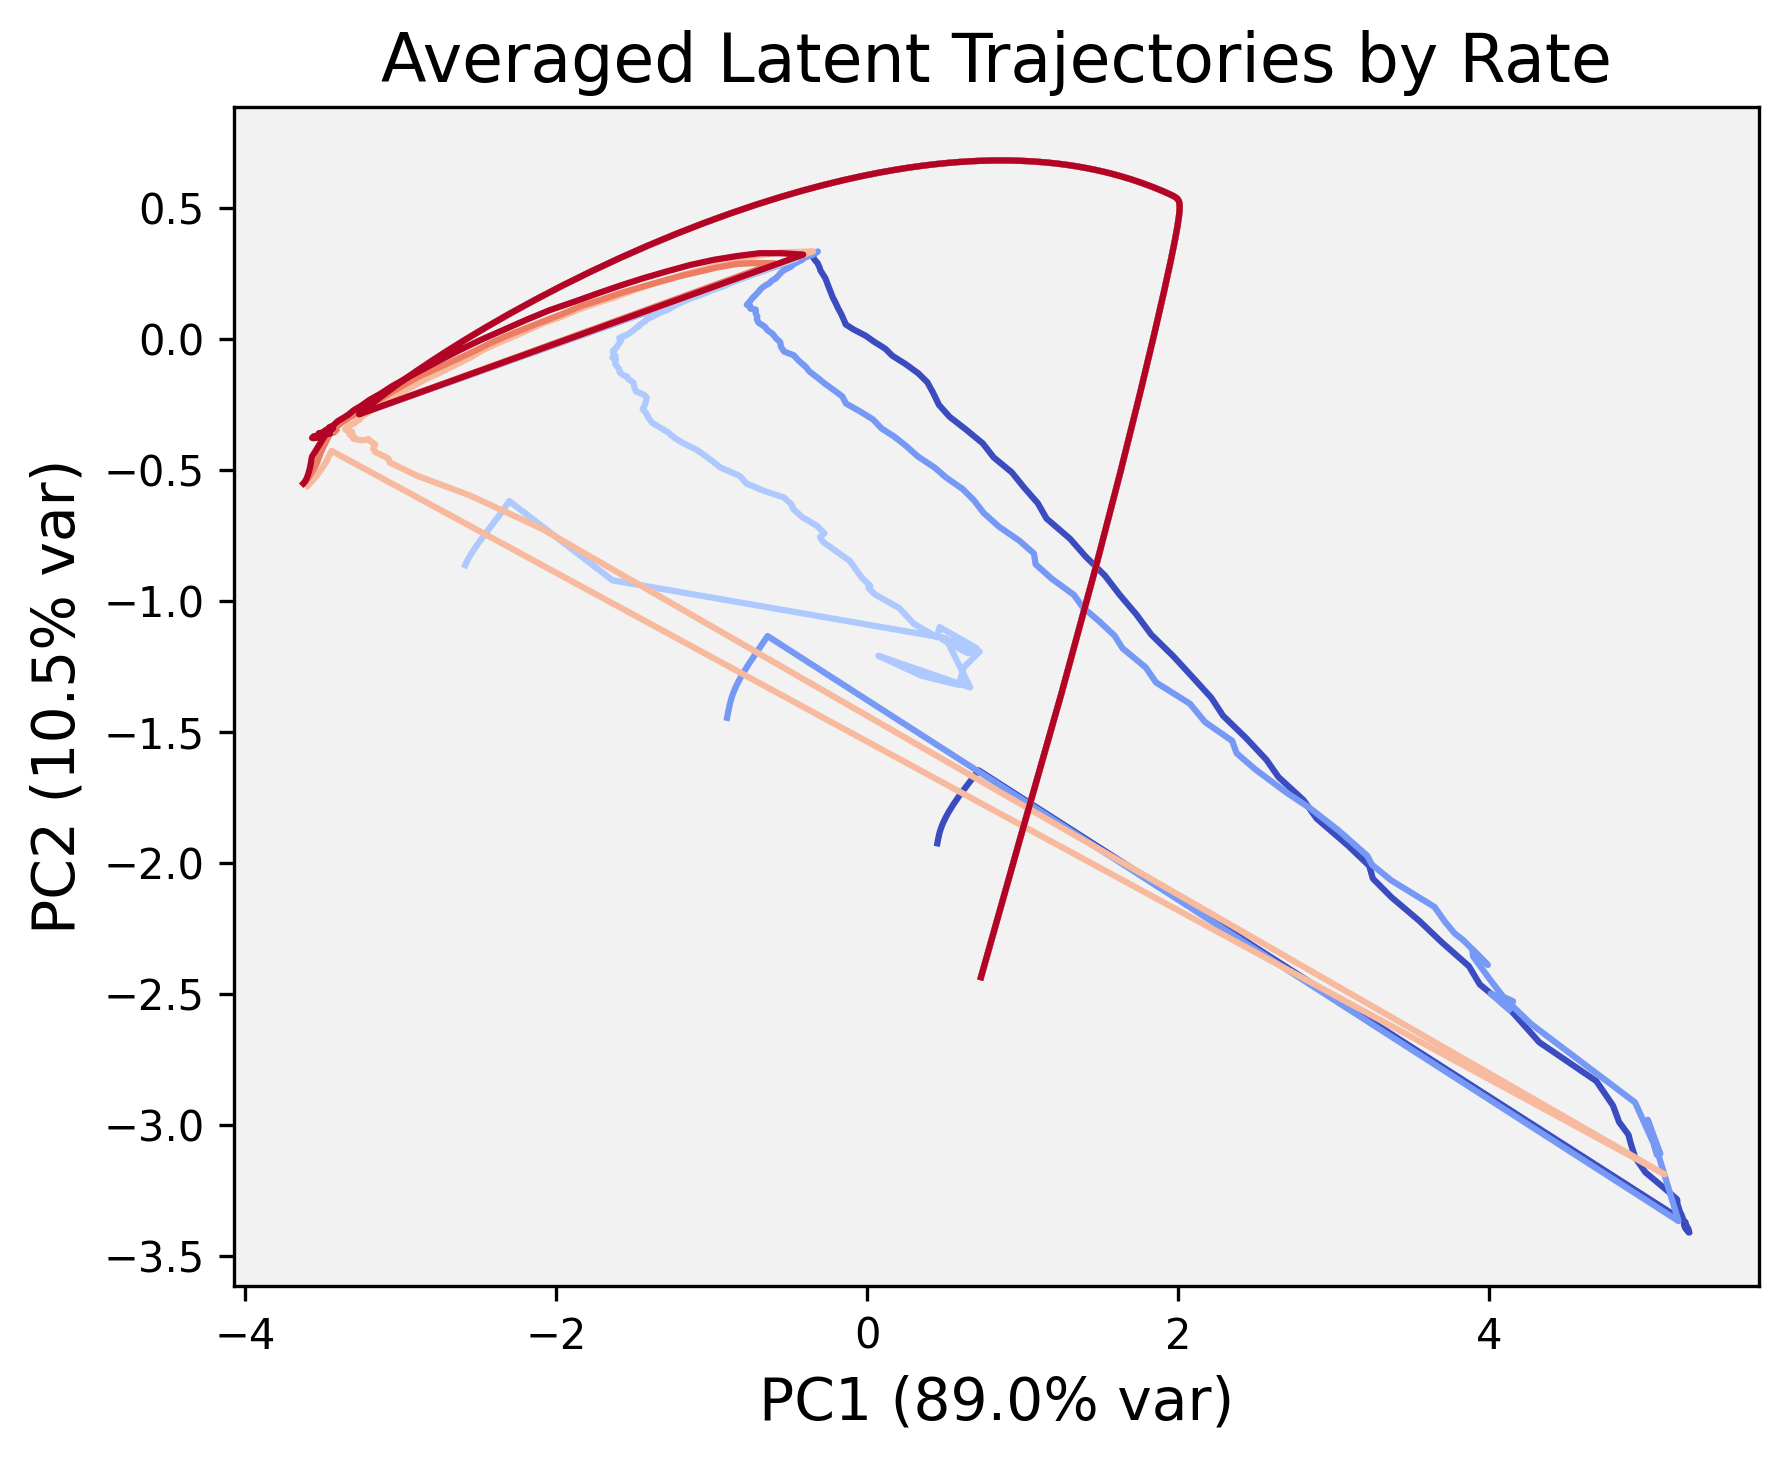

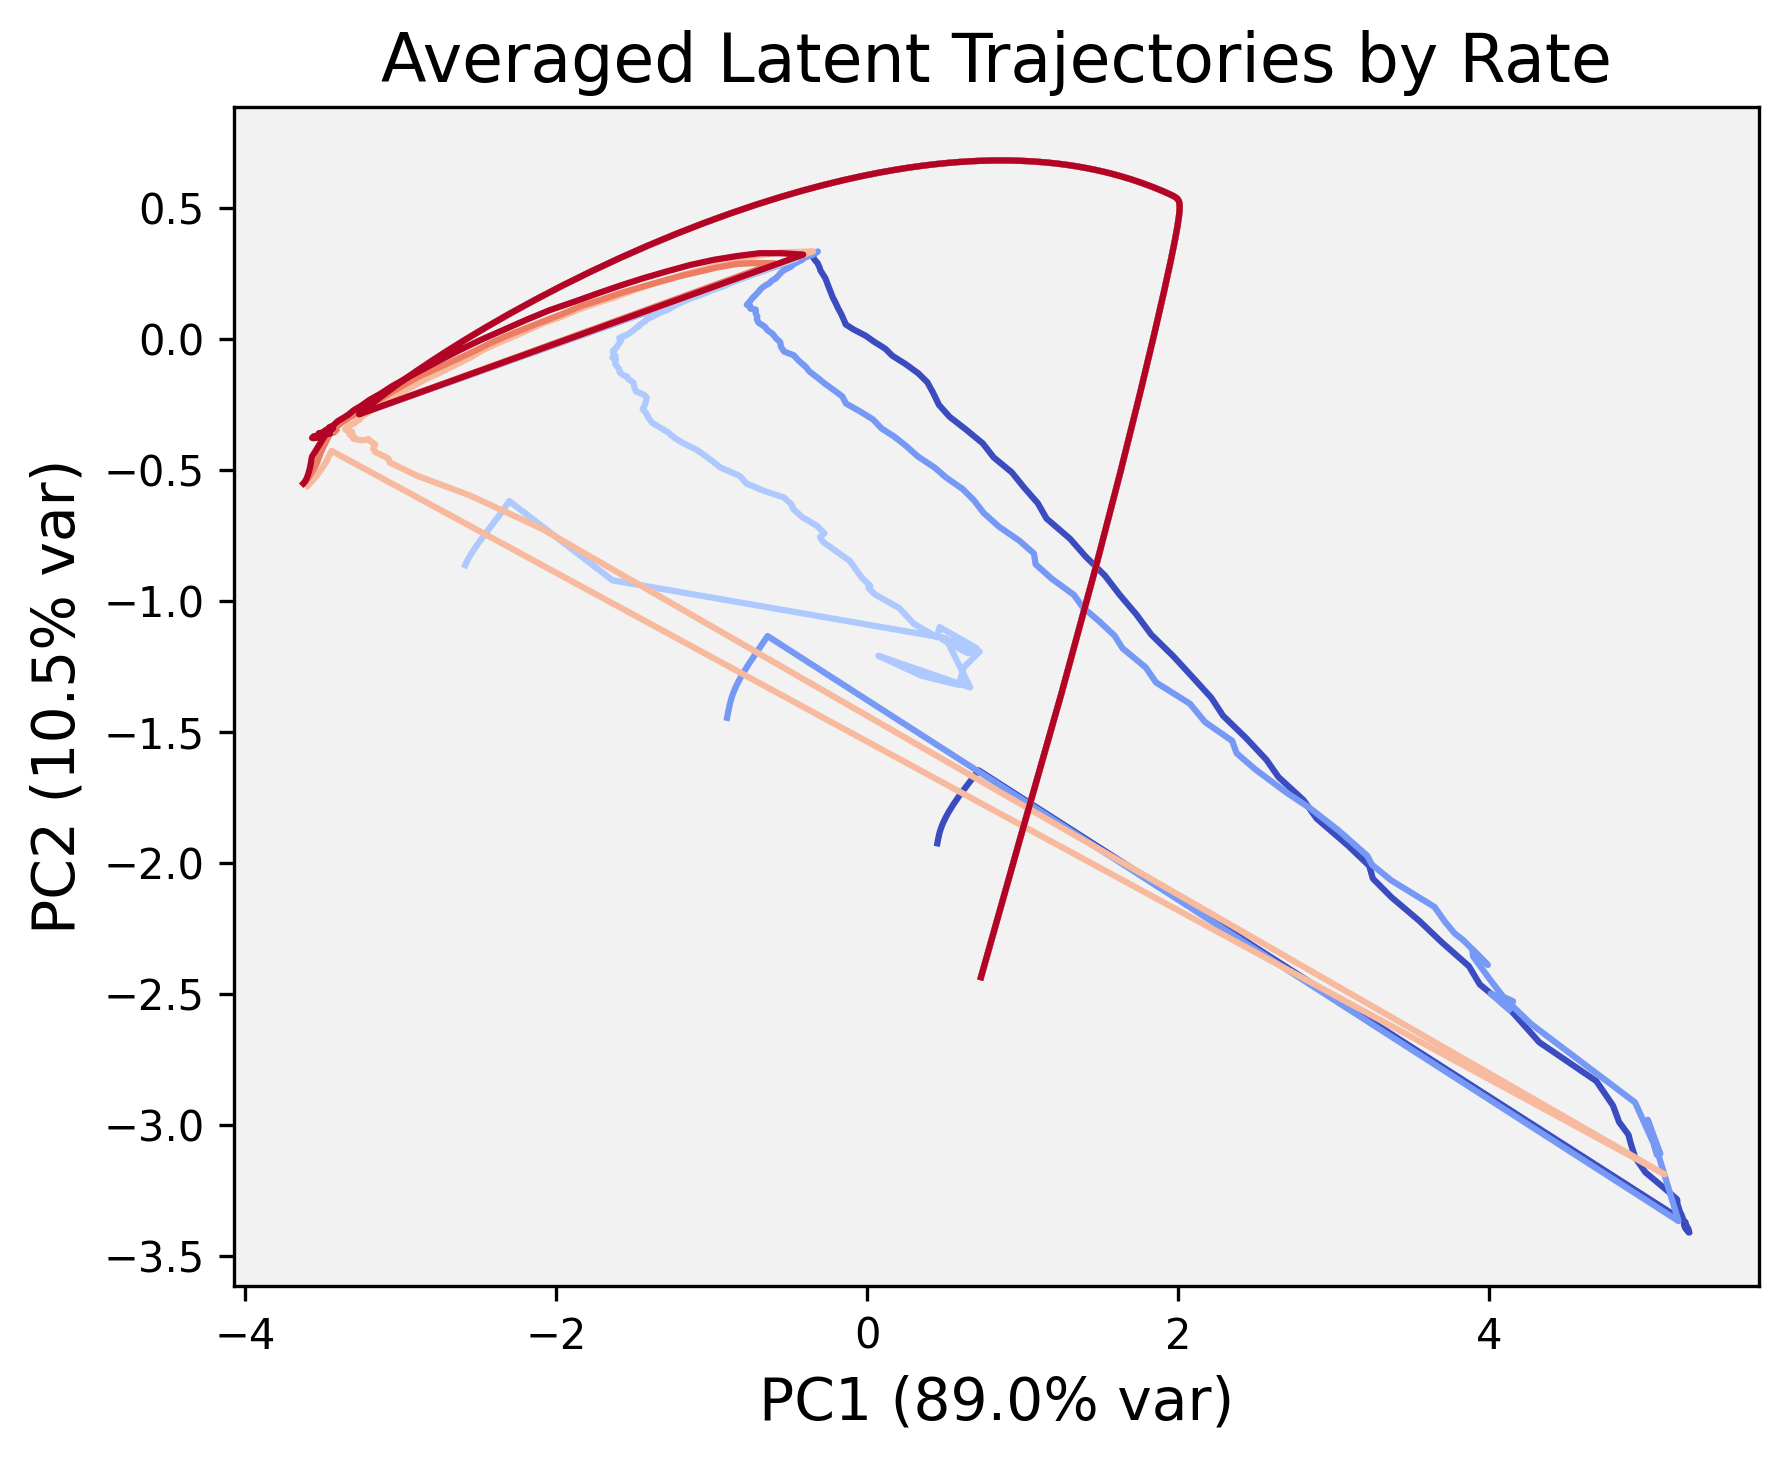

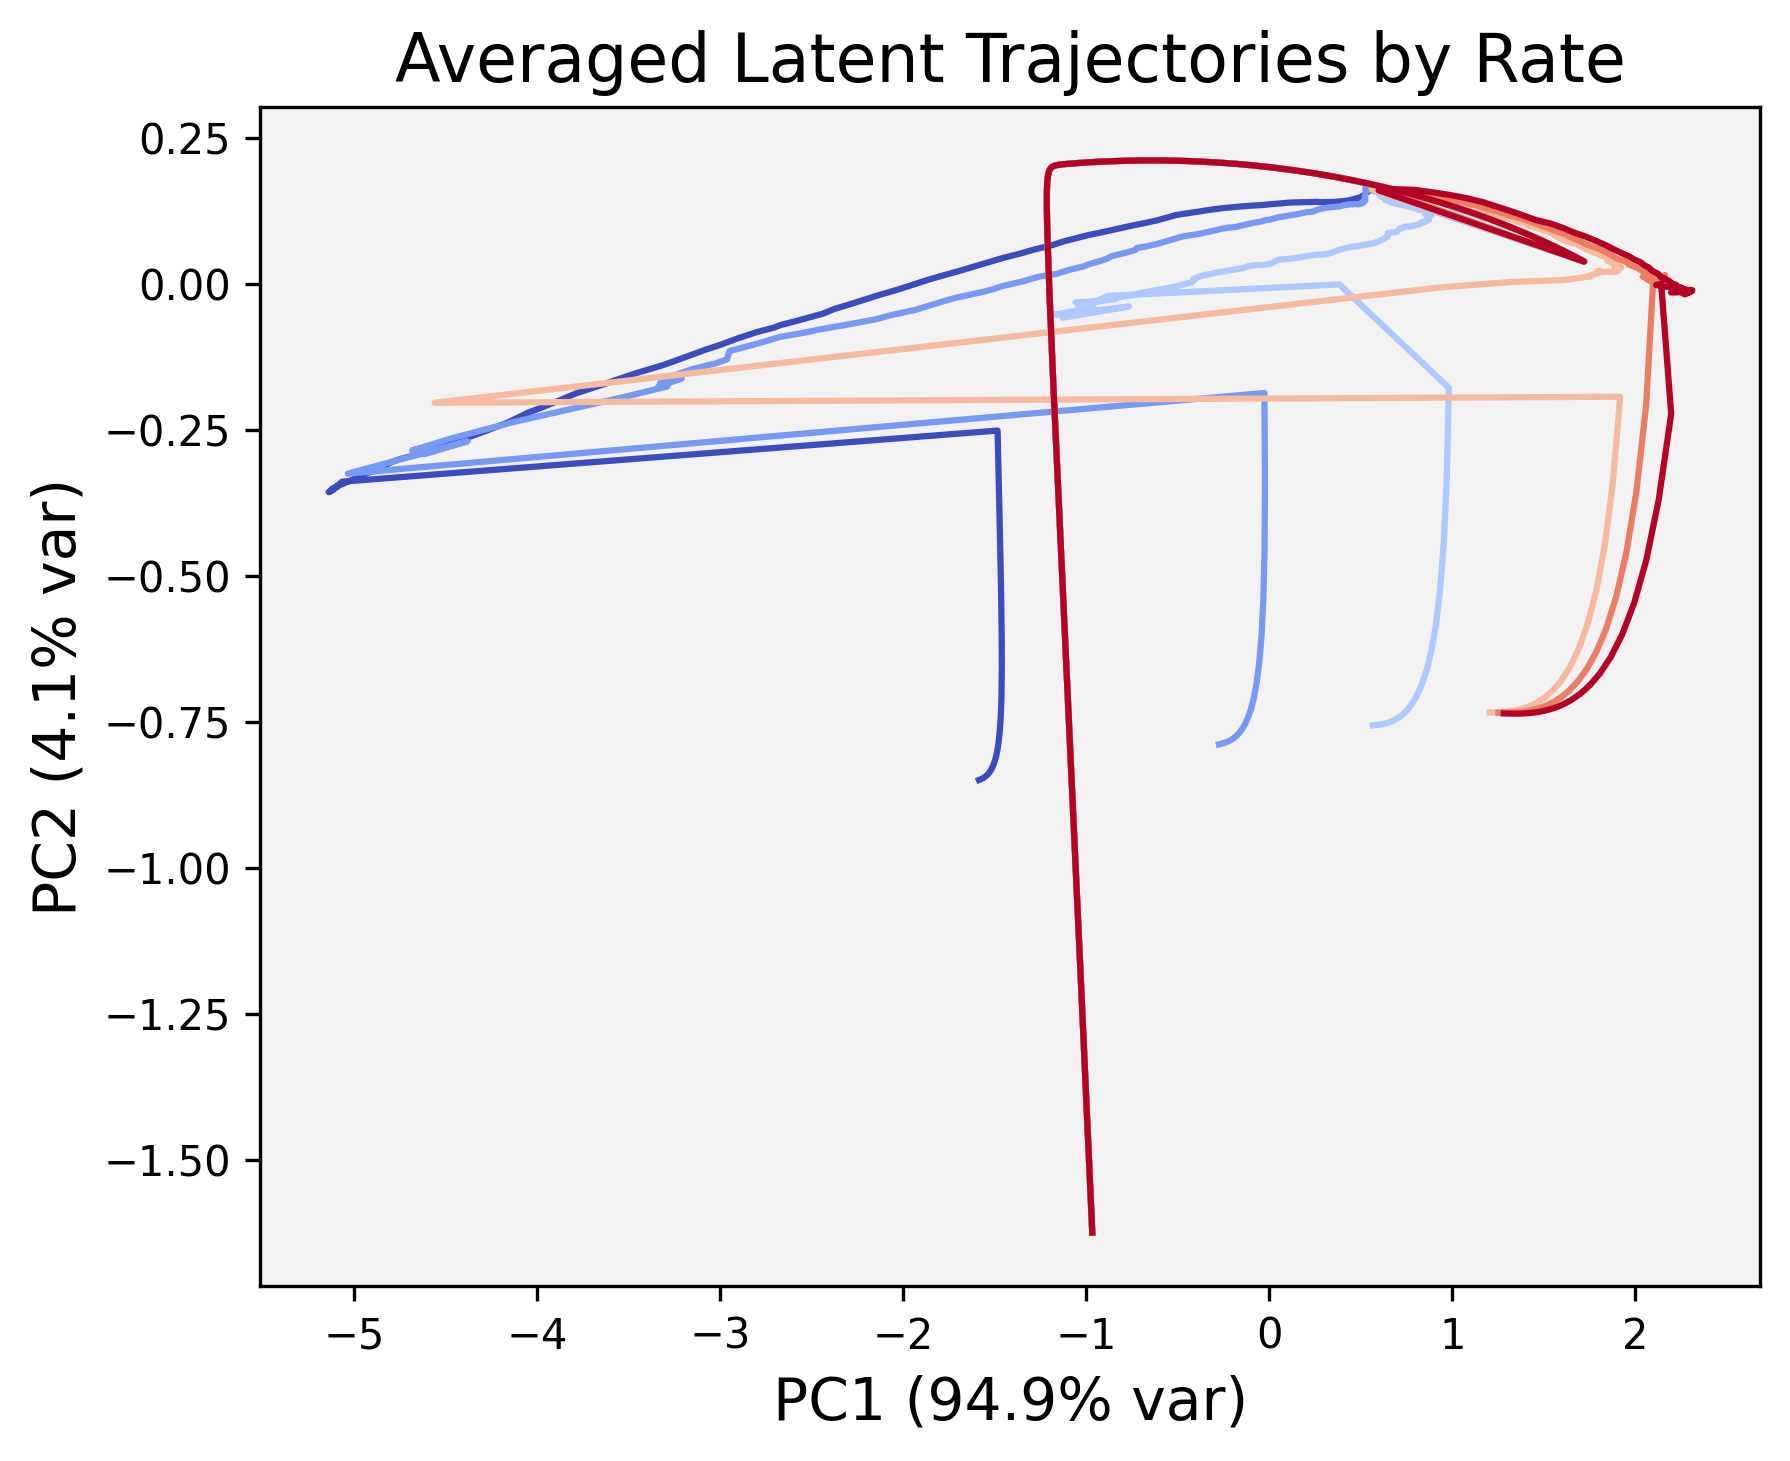

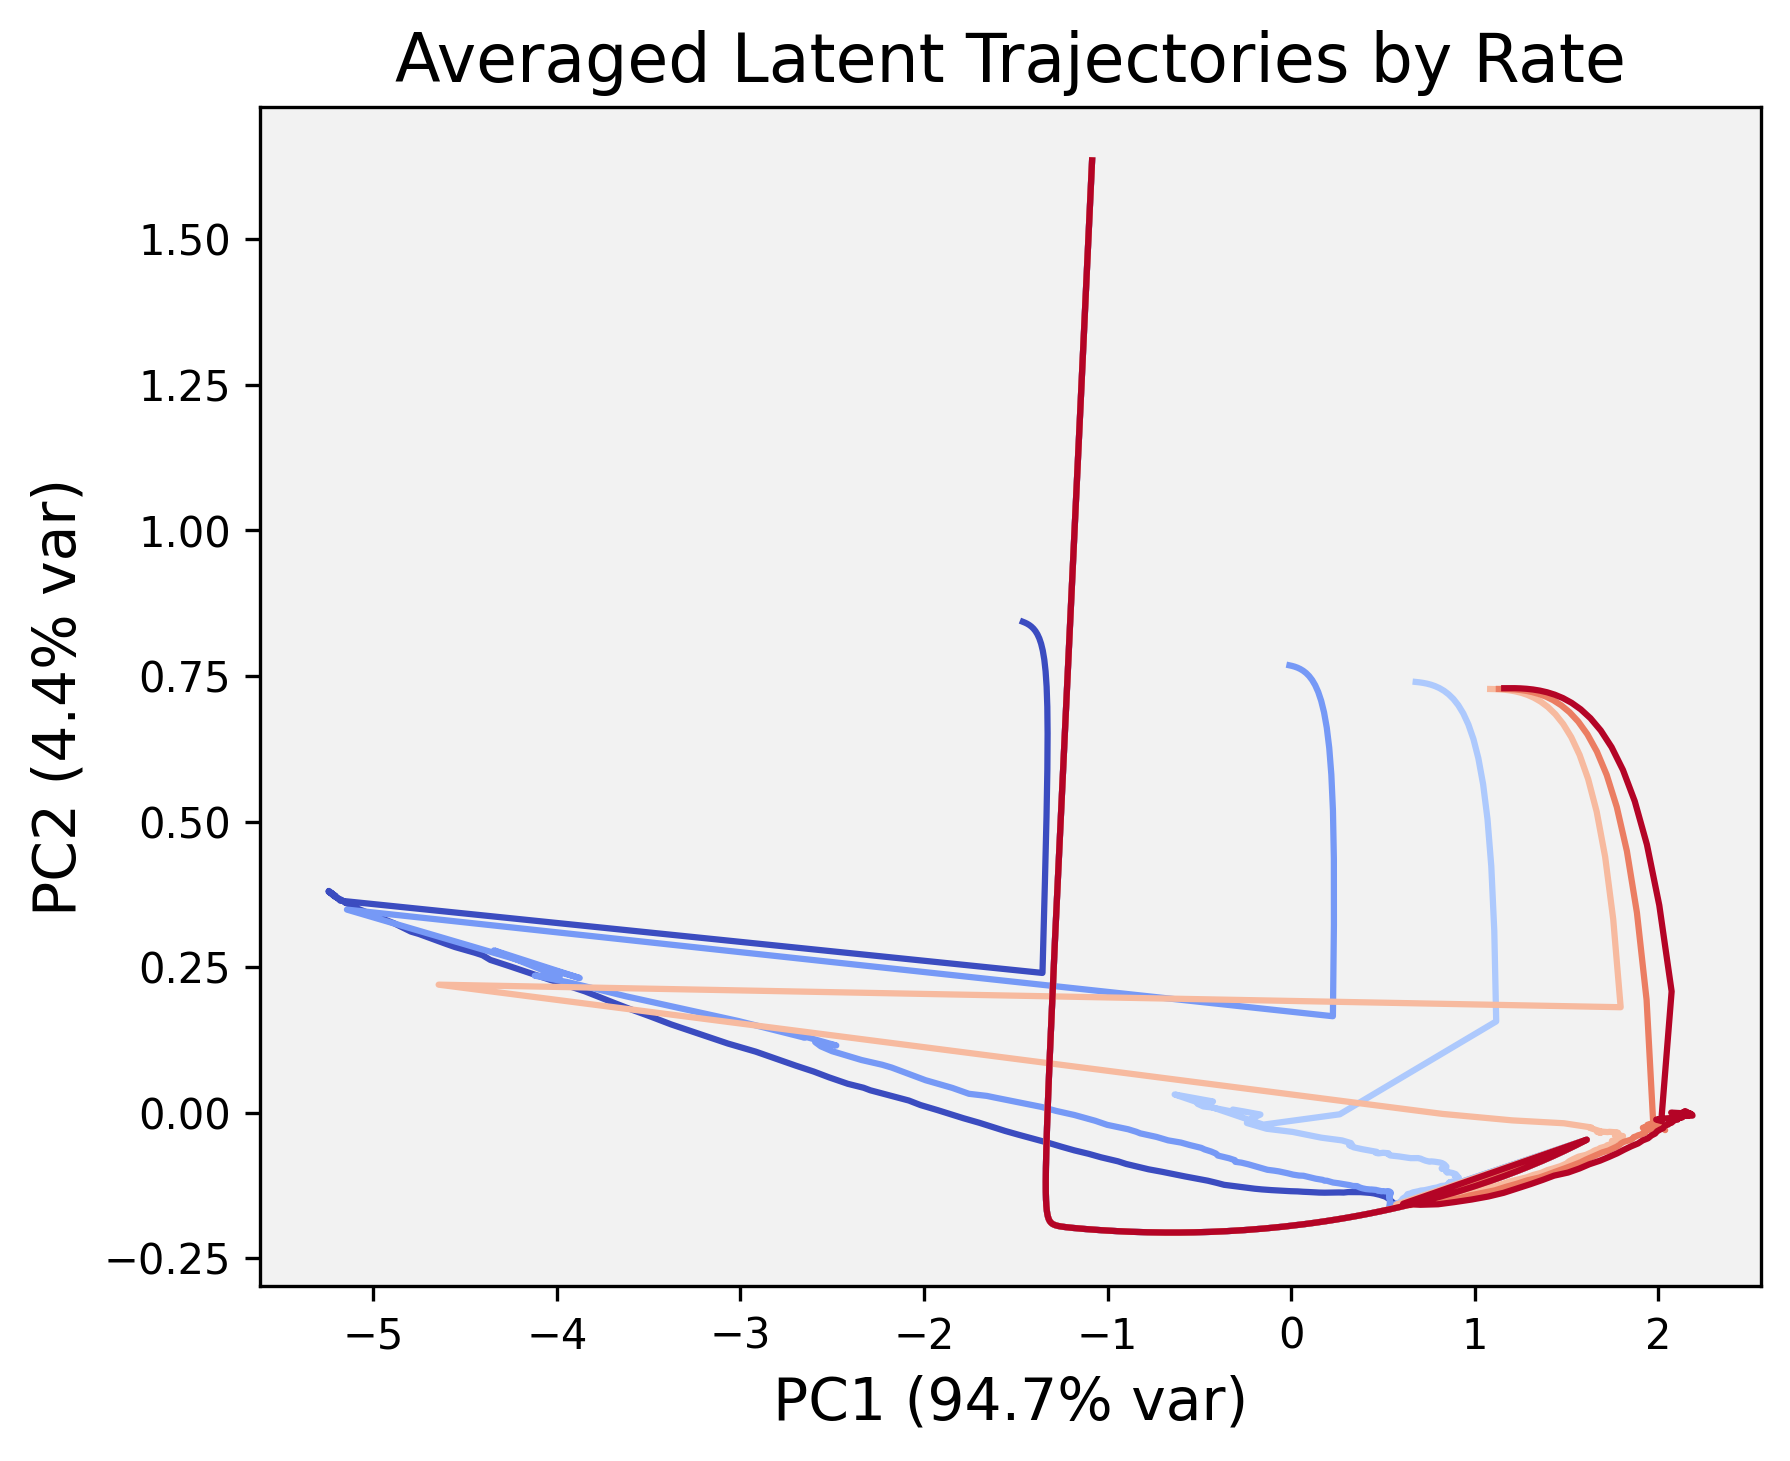

In [86]:
import pickle 
with open("pca_object_dd_axes.pkl", "rb") as file:
    PCA_GLOBAL = pickle.load(file)
    
task_dataset_dict=d1e2

inputs_latents = task_dataset_dict["inputs"]

PCA_GLOBAL 
for hashname, path in underfit_paths.items():
    
    with open(f"/scratch/gpfs/ad2002/fixed_points/fps_{hashname}_000.pkl", "rb") as file:
        fps = pickle.load(file)
        fps = fps[fps.qstar <= 1e-5]
                                                                # assuming alpha = 0.1 for DD but check
    cluster_centers, timescales, cluster_is_stable= compute_dynamical_metrics(fps, delta_t=0.01, alpha = 0.1)
#     for i,c in enumerate(cluster_centers):
#         print(c, timescales[i])

    print(hashname,path )
    dim = fps.xstar.shape[1]
    if dim == 2:
        print(fps.xstar.shape)
        continue
    
    analysis = Analysis_DD.create(run_name = hashname, 
                                        filepath = path + "/",
                                        model_type = "SAE")
    fig,ax = plot_trial_latents_new(analysis, num_trials=2000, 
                                    pca=True, 
                                    n_components=2, 
                                    avg_per_rate=True,
                                    xstar=fps.xstar, 
                                    is_stable=fps.is_stable, 
                                    phase="all", 
                                    inputs_latents=inputs_latents,
                                    plot_wrapper_trajs=False, 
                                    input_latents_extra=task_dataset_dict["extra"],
                                    scatter_trajectories=False,
                                    timescales=timescales,
                                    cluster_centers=cluster_centers,
                                    cluster_is_stable=cluster_is_stable,
                                    t_min=1e-2,
                                    t_max=1e2,
                                    pca_obj = PCA_GLOBAL,
                                    timescale_cmap=plt.get_cmap("plasma"),
                                    ics_dim=dim,
                                   )
    
    fig.set_dpi(300)
    fig.set_size_inches(6, 5)


In [2]:
# extract the parameters from file name for future reference

import re

f2 = "5_env_params_noise=0.0500,env_params_rateL=26,model_latent_size=2"
filename = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=1_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08"

# Regular expression to extract key-value pairs
matches = re.findall(r'([^=]+)=([^_]+)', filename)
m2 = re.findall(r'([^=]+)=([^_,]+)', f2)

# Convert to dictionary
params = {key: float(value) if '.' in value or 'E' in value else int(value) for key, value in matches}
p2 = {key: float(value) if '.' in value or 'E' in value else int(value) for key, value in m2}

tune params:  15_datamodule_file_index=50,model_latent_size=10,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.8118970394134521
completed?  False


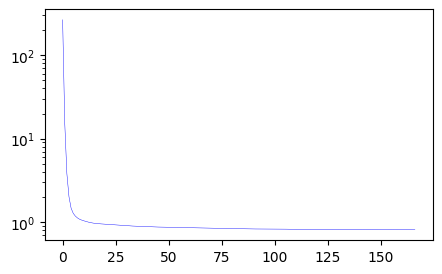

tune params:  1_datamodule_file_index=50,model_latent_size=2,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7875357270240784
completed?  False


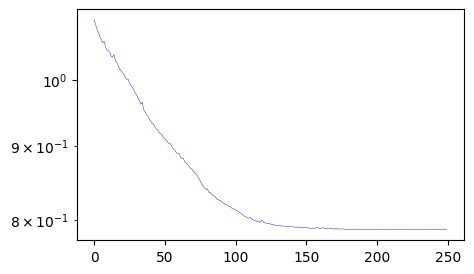

tune params:  12_datamodule_file_index=40,model_latent_size=5,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.900978982448578
completed?  False


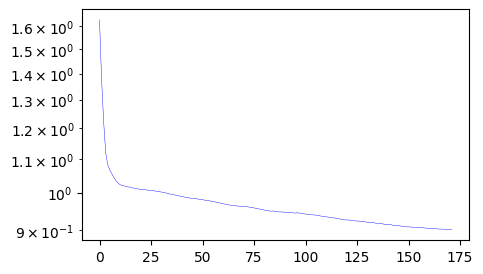

tune params:  6_datamodule_file_index=40,model_latent_size=10,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7856602668762207
completed?  False


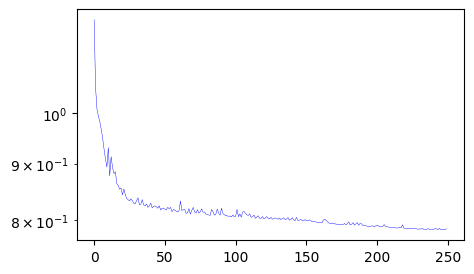

tune params:  3_datamodule_file_index=50,model_latent_size=3,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7857346534729004
completed?  False


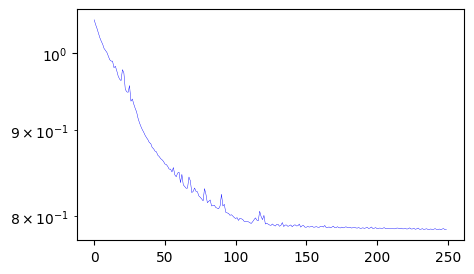

tune params:  2_datamodule_file_index=40,model_latent_size=3,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7853644490242004
completed?  False


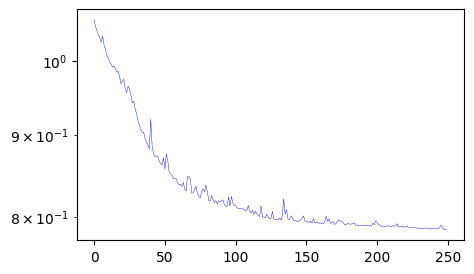

tune params:  7_datamodule_file_index=50,model_latent_size=10,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7844029068946838
completed?  False


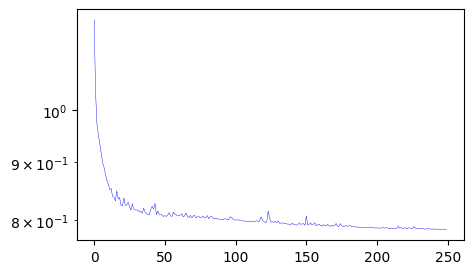

tune params:  5_datamodule_file_index=50,model_latent_size=5,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7838216423988342
completed?  False


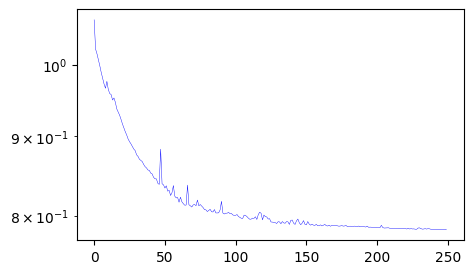

tune params:  8_datamodule_file_index=40,model_latent_size=2,model_lr=0.0001,model_weight_decay=0.0000
final loss:  1.0062386989593506
completed?  False


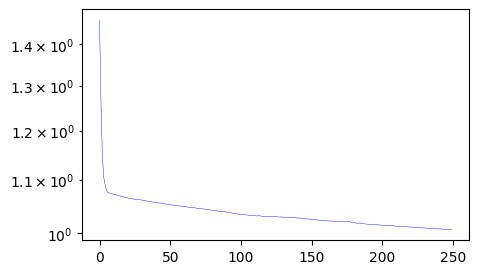

tune params:  11_datamodule_file_index=50,model_latent_size=3,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.9467056393623352
completed?  False


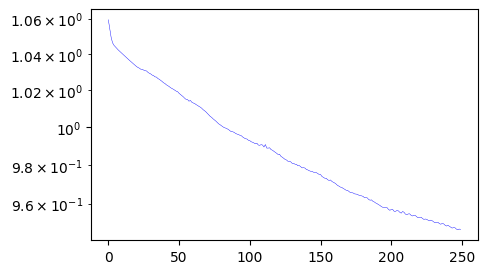

tune params:  4_datamodule_file_index=40,model_latent_size=5,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.7846747040748596
completed?  False


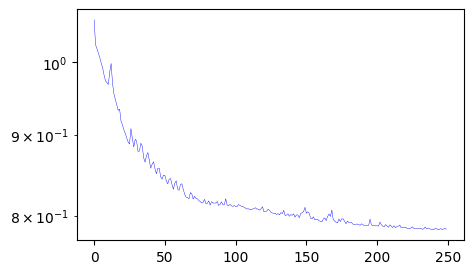

tune params:  9_datamodule_file_index=50,model_latent_size=2,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.980312168598175
completed?  False


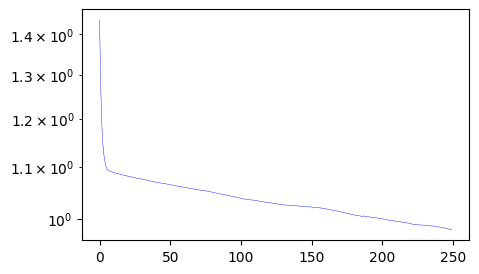

tune params:  14_datamodule_file_index=40,model_latent_size=10,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.8287171721458435
completed?  False


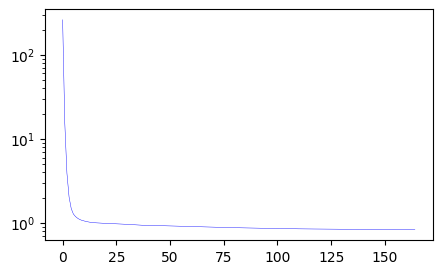

tune params:  0_datamodule_file_index=40,model_latent_size=2,model_lr=0.0010,model_weight_decay=0.0000
final loss:  0.788952648639679
completed?  False


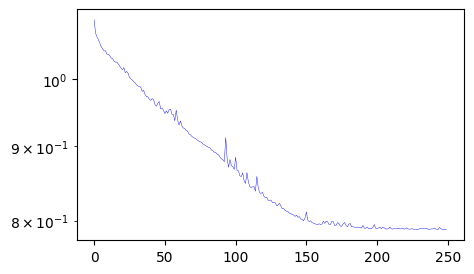

tune params:  10_datamodule_file_index=40,model_latent_size=3,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.9270050525665284
completed?  False


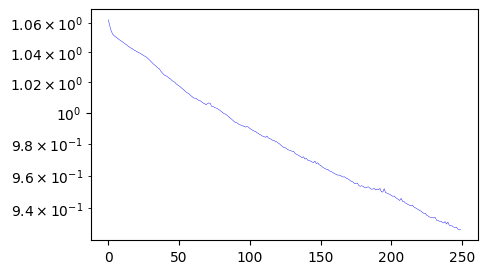

tune params:  13_datamodule_file_index=50,model_latent_size=5,model_lr=0.0001,model_weight_decay=0.0000
final loss:  0.9098527431488036
completed?  False


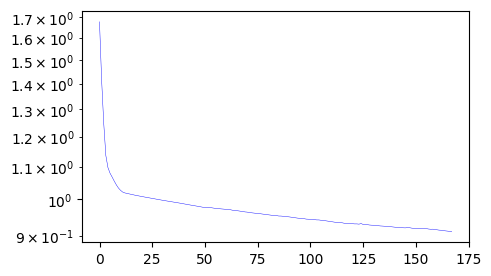

In [3]:
# iterate over all tune runs and
# 1. create analysis folders
# 2. print the final val/train loss for each + the training dynamics
# 2. plot the trial io AND flow field + latents
# 3. select the best ones

import os
import pandas as pd
import matplotlib.pyplot as plt
import json

RUN_DIR = "/scratch/gpfs/ad2002/content/runs/data-trained/20250327_NODE_on_PC_NODE_false_rateL26/train_PTL_2025-03-27_02-52-29"
TRAINED_MODELS_DIR = ""

TOTAL_ITERS = 1000
SHOW_LOSS_CURVES = True
FLOW_FIELD = False

dirs = os.listdir(RUN_DIR)
# retrieve the last training for that model and task
# latest_dir = dirs[len(dirs)-2]
# # get all hyperparam combs for the latest train run
# tunes = os.listdir(RUN_DIR + "/" + latest_dir)
good_loss = []

for tune in dirs:
    
    prog_path = RUN_DIR + "/" + tune + '/progress.csv'
    params_path = RUN_DIR + "/" + tune + '/params.json'
    if os.path.exists(prog_path):
        df = pd.read_csv(prog_path)
        loss = df.iloc[:, 0]
        print("tune params: ", tune)
        print("final loss: ", loss[len(loss)-1])
        print("completed? ", len(loss) == TOTAL_ITERS)

        if loss[len(loss)-1] <= 1e-4:
            good_loss.append(tune)
              
        if SHOW_LOSS_CURVES:
            fig, ax = plt.subplots(figsize=(5, 3), dpi=100)
            ax.plot(loss, linestyle="-", color="b", label="val loss", linewidth=0.3)
            ax.set_yscale('log')
            plt.show()

        if FLOW_FIELD:
            # create analysis object
            pass

for word in good_loss:
    print(word + '\n')


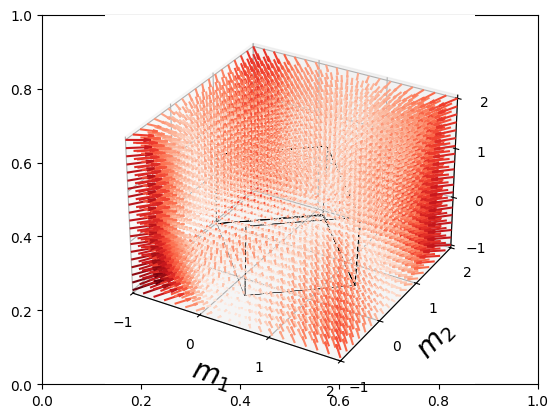

In [1]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_NODE/max_epochs=1000_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=1.00E-01_latent_size=3_layer_hidden_size=64"
node_3bff = Analysis_TT(run_name = "node_3bff", filepath = path + "/")

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250319_3BFF_full_testFP/max_epochs=500_weight_decay=1.00E-08_learning_rate=5.00E-03_seed=0_noise=5.00E-02_latent_size=128"
full_3bff = Analysis_TT(run_name = "full_3bff", filepath = path + "/")

# node_3bff.plot_trial_io(num_trials = 2)
# node_3bff.plot_trial_latents(num_trials = 10)

# testing if FP finder works for FullRankRNN and LowRankRNN
# fps, xstar, q_flag, colors = node_3bff.plot_fps(
#                     num_traj=10,
#                     n_inits=1024,
#                     noise_scale=0.0,
#                     learning_rate=1e-3,
#                     max_iters=10000,
#                     device="cpu",
#                     seed=0,
#                     compute_jacobians=True,
#                     q_thresh=1e-3,
#                     n_pca_components=3,
#                     return_pca_model = False,
#                     do_pca=False,
#                     plot_only_points=False,
#                     return_points = True,
#                 )

node_3bff.plot_flow_field(latents_range = [[-1,2],[-1,2],[-1,2]], num_points = 20, inputs = None, xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=2, cmap=plt.cm.Reds, scatter_trajectories=False,
                        params = None, noiseless=False)

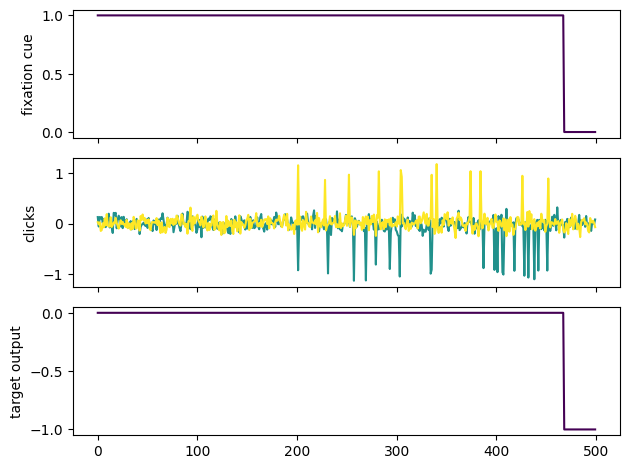

In [1]:
## Pclicks task - just like Luo et al 2023
from ctd.task_modeling.task_env.task_env import PClicks

pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz

pc.render()

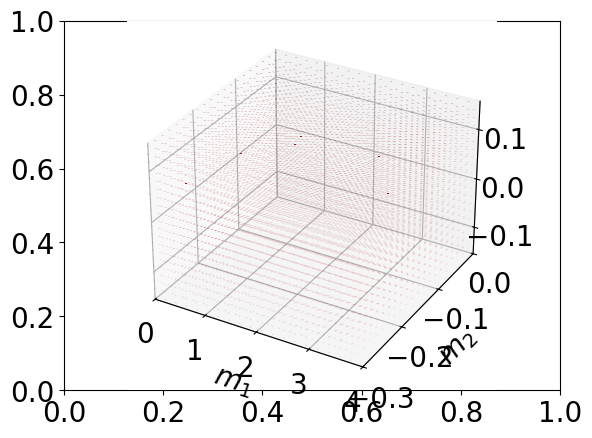

In [4]:
# first very short training on PClicks - loss was 0 always and something is prob wrong
from ctd.comparison.analysis.tt.tt import Analysis_TT

# 39:1 ratio should be very easy
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250316_PClicks_NODE"
tune39 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune39_2lat = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune26 = "max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_rateL=26_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-10"

node_pclicks_39 = Analysis_TT(run_name = "node_pclicks_39", filepath = path + "/" + tune39 + "/")
node_pclicks_26 = Analysis_TT(run_name = "node_pclicks_26", filepath = path + "/" + tune26 + "/")
node_pclicks_39_2lat = Analysis_TT(run_name = "node_pclicks_39_2lat", filepath = path + "/" + tune39_2lat + "/")

# node_pclicks_39.plot_trial_io(num_trials = 3)
# node_pclicks_26.plot_trial_io(num_trials = 3)
# node_pclicks_39_2lat.plot_trial_io(num_trials = 3)

# # NOTE that running pca takes maximum variance and plotting the trajectories might magnify any noise in them

# # choose pca and/or tsne when >3 latents
# node_pclicks_26.plot_trial_latents(num_trials = 50, reduce_3_latents=False, pca=True)
# node_pclicks_39.plot_trial_latents(num_trials = 20, reduce_3_latents=False, pca=True)
# node_pclicks_39_2lat.plot_trial_latents(num_trials = 20, reduce_3_latents=False, pca=True)

# # NO FIXED POINTS SHOULD BE FOUND - then what is the point of DSAAAA
# # plot the trajs and fixed points
# node_pclicks_39_2lat.plot_fps(
#                     num_traj=10,
#                     n_inits=1024,
#                     noise_scale=0.0,
#                     learning_rate=1e-3,  # higher LR brings up spurious unstable points
#                     max_iters=10000,
#                     device="cpu",
#                     seed=0,
#                     compute_jacobians=True,
#                     q_thresh=1e-6,
#                     n_pca_components=3,
#                     return_pca_model = False,
#                     do_pca=False,
#                     plot_only_points=False,
#                     return_points = False,
#                 )

# the fixed points for the well trained model are clearly coherent with previous lit

node_pclicks_39.plot_flow_field(latents_range = [[0,4],[-0.3,0],[-0.15,0.15]], num_points = 20, inputs = None, xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=0, cmap=plt.cm.Reds, scatter_trajectories=False,
                        params = None, noiseless=False)

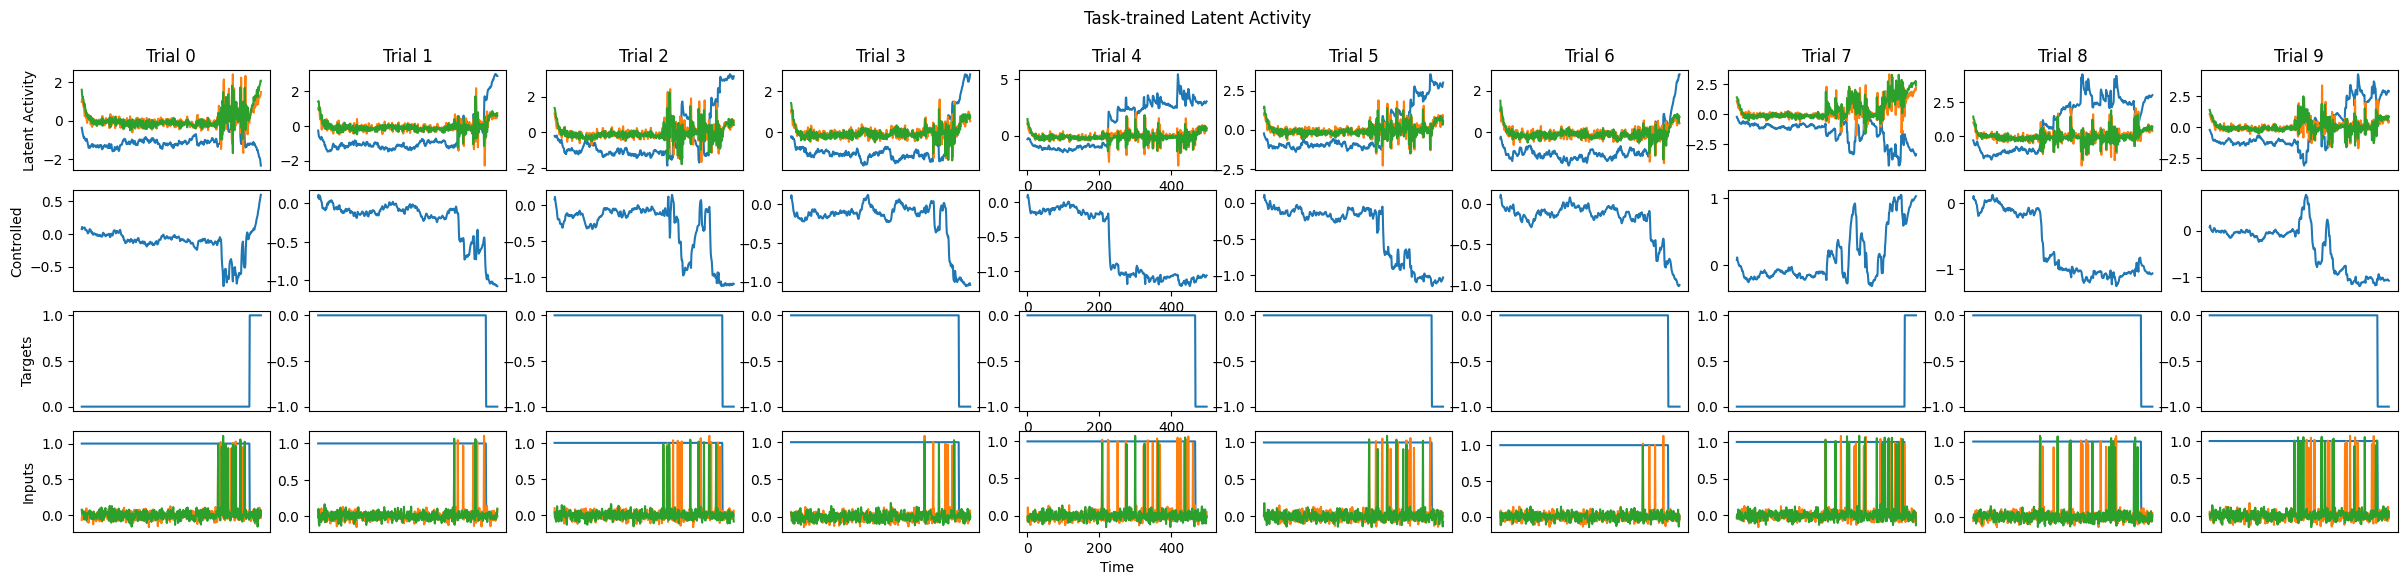

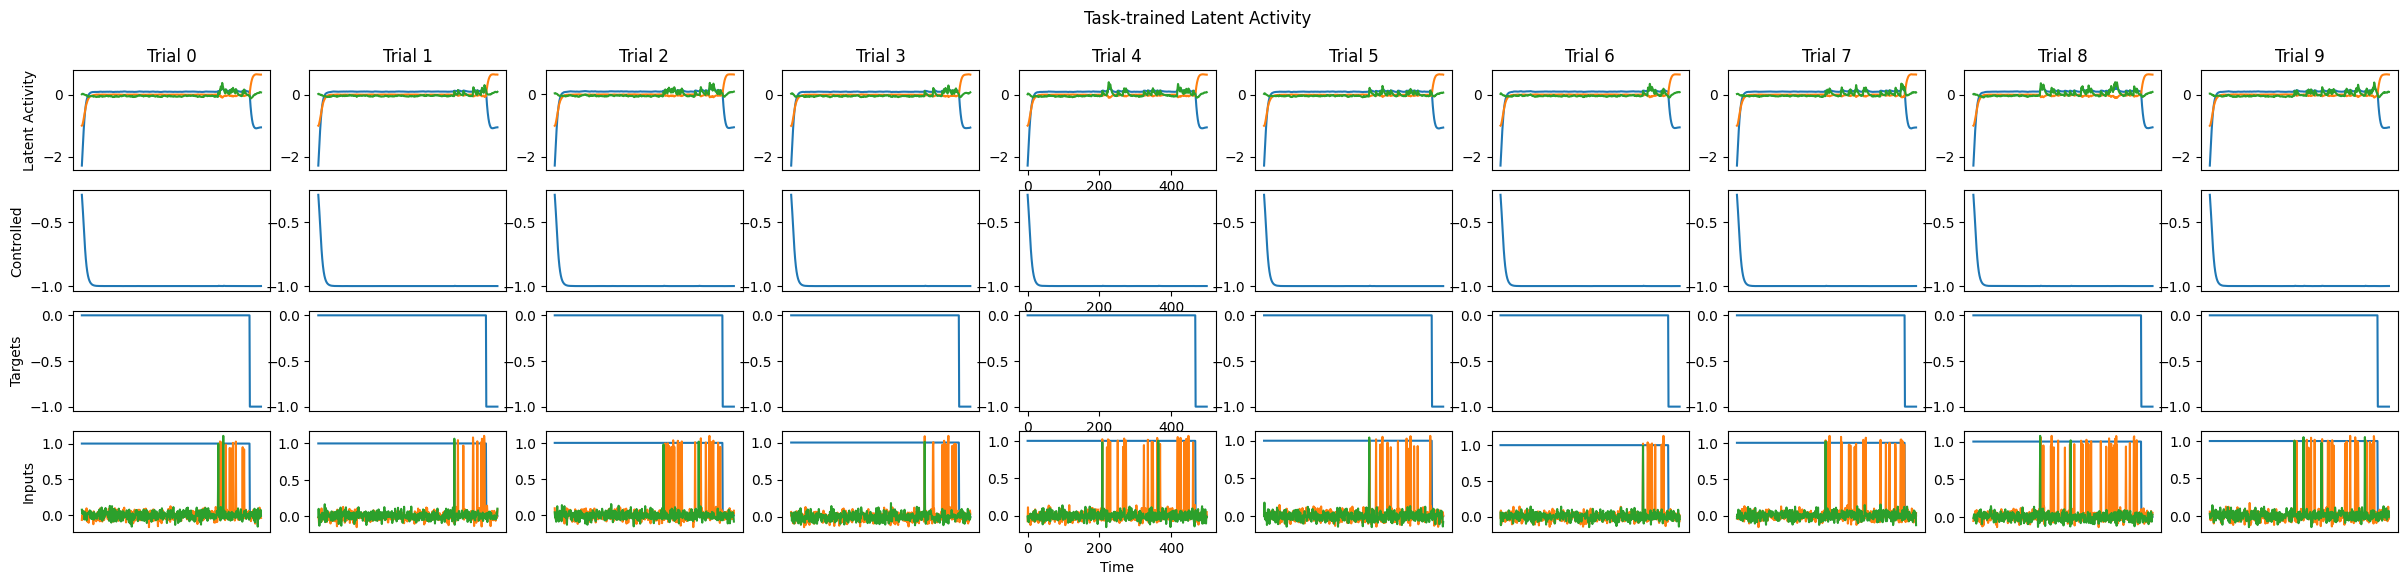

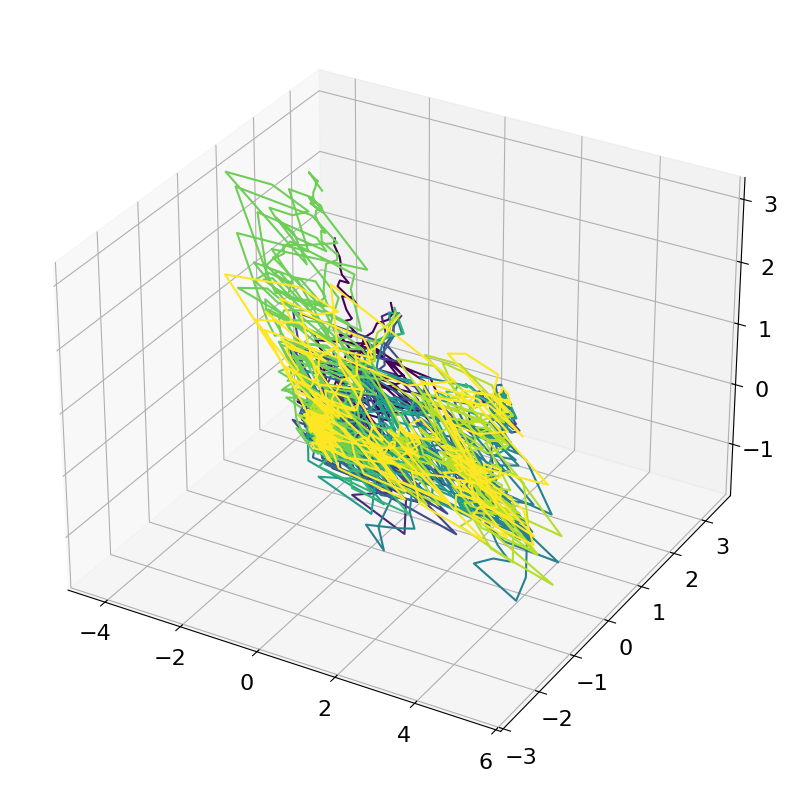

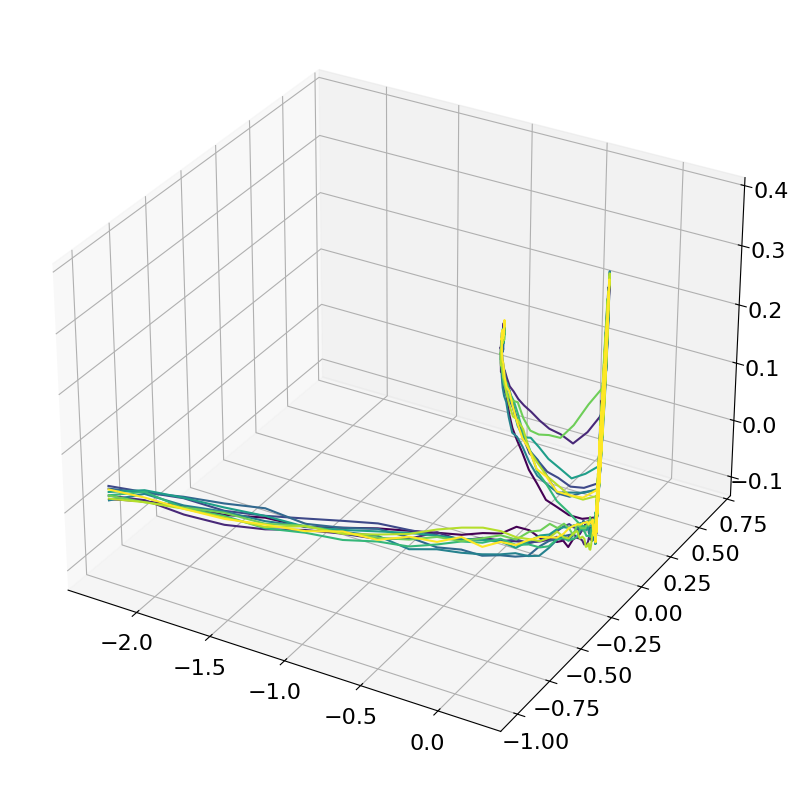

AttributeError: 'function' object has no attribute 'to'

In [3]:
# FullRankRNN

from ctd.comparison.analysis.tt.tt import Analysis_TT

# 26 not good
tune26 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_26/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=26_latent_size=64"
# 39 good - tbh could just guess one side always and still not lose much
tune39 = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250318_PClicks_full_39/max_epochs=500_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=16"

full_pclicks_26 = Analysis_TT(run_name = "full_pclicks_26", filepath = tune26 + "/")
full_pclicks_39 = Analysis_TT(run_name = "full_pclicks_39", filepath = tune39 + "/")

# io is showing PCA latents
full_pclicks_26.plot_trial_io(num_trials=10)
full_pclicks_39.plot_trial_io(num_trials=10)

# also showing PCA
full_pclicks_26.plot_trial_latents(num_trials=10)
full_pclicks_39.plot_trial_latents(num_trials=10)

# plot the trajs and fixed points - NEED CELL
full_pclicks_39.plot_fps(
                    num_traj=10,
                    n_inits=2048,
                    noise_scale=0.0,
                    learning_rate=1e-3,  # higher LR brings up spurious unstable points
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-5,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=False,
                    plot_only_points=False,
                    return_points = False,
                )

In [ ]:
# visualize simulated neural dataset
import h5py

# LIKE THE LUO 2023 PAPER: simulate dataset with the same number of neurons, trials, and firing rate as the real data

# easy pclicks trials simulated from NODE
path = "/scratch/gpfs/ad2002/content/datasets/dt/20250316_PClicks_NODE/max_epochs=250_weight_decay=1.00E-10_learning_rate=1.00E-02_seed=0_noise=5.00E-02_rateL=39_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-10"
tune = "heldin_50_heldout_10_obs_noise_pseudoPoisson_dispersion_1.0_seed_0.h5"
sim_data = path + "/" + tune

# this is from the data_training datamodule
with h5py.File(data_path, "r") as h5file:
    # Load the data
    train_data = to_tensor(h5file["train_encod_data"][()])
    valid_data = to_tensor(h5file["valid_encod_data"][()])
    train_recon_data = to_tensor(h5file["train_recon_data"][()])
    valid_recon_data = to_tensor(h5file["valid_recon_data"][()])
    # Load the activity
    train_activity = to_tensor(h5file["train_activity"][()])
    valid_activity = to_tensor(h5file["valid_activity"][()])
    # Load the latents
    train_latents = to_tensor(h5file["train_latents"][()])
    valid_latents = to_tensor(h5file["valid_latents"][()])
    # Load the indices
    train_inds = to_tensor(h5file["train_inds"][()])
    valid_inds = to_tensor(h5file["valid_inds"][()])
    # Load other parameters
    self.orig_mean = h5file["orig_mean"][()]
    self.orig_std = h5file["orig_std"][()]
    self.readout = h5file["readout"][()]
    train_inputs = h5file["train_inputs"][()]
    valid_inputs = h5file["valid_inputs"][()]
    train_extra = h5file["train_extra"][()]
    valid_extra = h5file["valid_extra"][()]

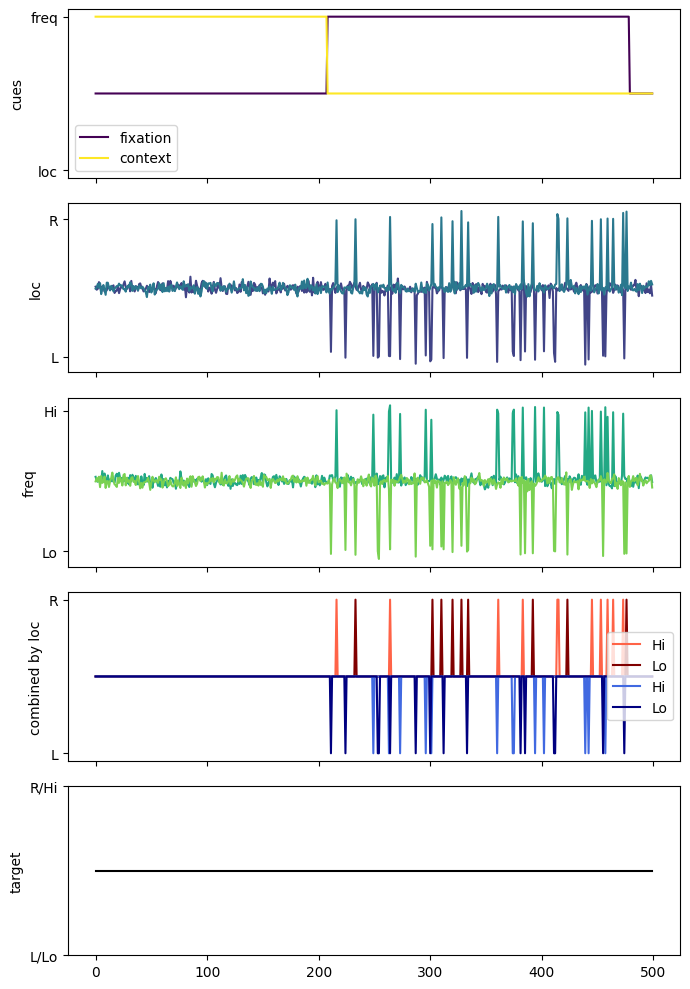

In [8]:
## Marino Pagan task - just like the paper
# note that there is a very small but non-zero chance that the target output should be 0 (if everything has tied)

from ctd.task_modeling.task_env.task_env import MarinoPagan

mp = MarinoPagan(n_timesteps= 500, noise= 0.05, rateL=20)  # Hz

mp.render()

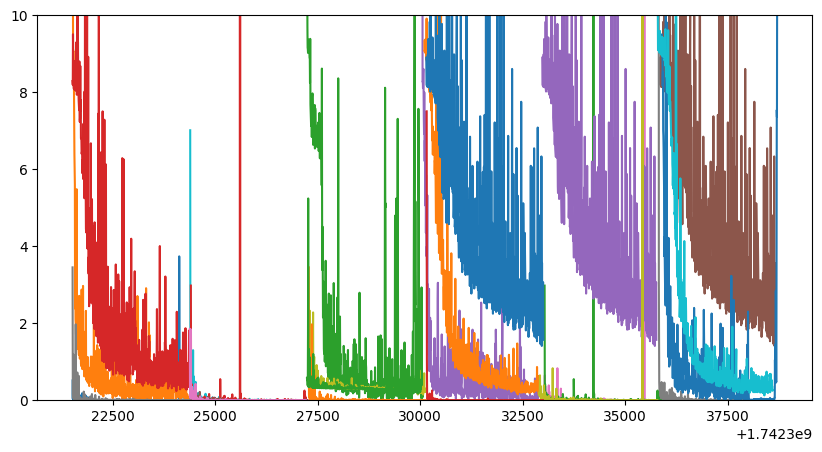

In [13]:
# compare the training dynamics of all tunes for one model on one task
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_progress_files(directory):
    progress_files = []
    labels = []
    
    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        progress_file = os.path.join(folder_path, 'progress.csv')
        
        if os.path.isdir(folder_path) and os.path.isfile(progress_file) and os.path.getsize(progress_file) > 0:
            progress_files.append(progress_file)
            labels.append(folder_path)
    
    return progress_files, labels

# partial NODE in TEST
# dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250316_PClicks_NODE/train_2025-03-16_21-29-27/"

# full NODE in SHARE - the second blue explodes in gradient: rate 1, latent 10 - got 24 out of the total 48, but prob can get one of each 
# type save the learning rate...
dir = "/scratch/gpfs/ad2002/content/runs/task-trained/20250318_PClicks_NODE_full/train_2025-03-18_14-11-40"

fig, ax = plt.subplots(figsize=(10, 5))
progress_files, labels = find_progress_files(dir)
for i in range(len(progress_files)):  
    file = progress_files[i]
    df = pd.read_csv(file)
    ax.plot(df['timestamp'], df['loss'], label=labels[i])
    #ax.legend()

ax.set_ylim([0, 10])

plt.show()

# plotting both easy and hard trials: for easy size 2 lr 1e-2 is the best (3-10 not necesarily better, but higher lr means more spikey),
# for 26 size 10 is best

# could increase the lat weight to make the latents more stable